001_Run_Model is used to run the calliope model of choice and stores the results in the correct location .

In [1]:
import sys
print(sys.version)

3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:49:16) [MSC v.1929 64 bit (AMD64)]


In [ ]:

import os
import pandas as pd
import calliope

cluster_type = 'Spectral'
cluster_number = 'k3'
percentile = '90'

# Enable detailed logging to see model building and solving progress
calliope.set_log_verbosity('INFO', include_solver_output=True)

model = calliope.Model('model_v_6/model.yaml')

model.run()

path_main = f"data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/{cluster_type}/{cluster_type}_{cluster_number}/{percentile}_percentile_timeseries/{cluster_type}_{percentile}_{cluster_number}_bidirectional_rerun" # This is for the updated tech
model.to_netcdf(path_main+".nc")


[2026-04-28 14:24:16] INFO     Model: initialising
[2026-04-28 14:24:17] WARNING  c:\Users\Benhd\Code\envs\calliope-env\lib\site-packages\calliope\exceptions.py:60: ModelWarning:

Possible issues found during model processing:
 * `demand_ammonia` at `region_49_5_35_25` defines force_resource but not a finite resource, so force_resource will not be applied


[2026-04-28 14:24:17] INFO     Model: preprocessing stage 1 (model_run)
[2026-04-28 14:24:17] INFO     Model: preprocessing stage 2 (model_data)
[2026-04-28 14:24:45] INFO     Model: time resampling/clustering complete
[2026-04-28 14:24:45] INFO     Model: preprocessing complete
[2026-04-28 14:24:45] INFO     Backend: starting model run
[2026-04-28 14:24:45] INFO     Loading sets
[2026-04-28 14:24:45] INFO     Loading parameters
[2026-04-28 14:24:46] INFO     constraints are loaded in the following order: ['capacity', 'costs', 'dispatch', 'energy_balance', 'network', 'policy', 'conversion', 'conversion_plus', 'group', 'export', 'mil

PermissionError: [Errno 13] Permission denied: b'c:\\Users\\Benhd\\OneDrive\\Documents\\Oxford\\Year 4\\4YP\\Code\\Detecco-Ukraine\\data_prep\\Clustering_Output\\KNN_Graph_output\\nodal_ammonia_bidirectional\\Spectral\\Spectral_k3\\90th_percentile_timeseries\\Spectral_90th_k3_bidirectional_rerun.nc'

In [3]:
cluster_type = 'Spectral'
cluster_number = 'k3'
percentile = '90'

path_main = f"data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/{cluster_type}/{cluster_type}_{cluster_number}/{percentile}_percentile_timeseries/{cluster_type}_{percentile}_{cluster_number}_bidirectional_rerun" # This is for the updated tech
model.to_netcdf(path_main+".nc")

[2026-04-28 14:35:54] INFO     Adding model run data to model data attributes
[2026-04-28 14:35:56] INFO     Converting boolean attrs to ints
[2026-04-28 14:35:56] INFO     Converting None attrs to 'None'
[2026-04-28 14:35:56] INFO     Converting object coordinates to string
[2026-04-28 14:35:56] INFO     Converting object variables with boolean content to float
[2026-04-28 14:35:56] INFO     Saving to NetCDF


In [6]:
def summarize_model_results(model, run_name):
    """Extract key metrics for model comparison - LIFETIME COST FOCUS"""
    
    cost_invest = model.results['cost_investment'].to_dataframe().reset_index()
    total_capex_once = cost_invest['cost_investment'].sum()
    
    energy_cap = model.results.energy_cap.to_dataframe()
    energy_cap['tech'] = energy_cap.index.get_level_values('loc_techs').str.split('::').str[-1].str.split(':').str[0]
    
    carrier_prod = model.results.carrier_prod.sum(dim='timesteps').to_dataframe().reset_index()
    carrier_prod['carrier'] = carrier_prod['loc_tech_carriers_prod'].str.split('::').str[-1]
    
    storage_cap = model.results.storage_cap.to_dataframe()
    
    # Get total costs (includes CAPEX annualized + OPEX for this year)
    cost_total = model.results['cost'].to_dataframe().reset_index()
    annual_total_cost = cost_total['cost'].sum()  # kUSD per year
    
    # Get levelised costs by carrier
    lcoe_df = model.results['total_levelised_cost'].to_dataframe().reset_index()
    
    # Production by carrier (MWh for full year)
    ammonia_prod = carrier_prod[carrier_prod['carrier'] == 'ammonia']['carrier_prod'].sum()
    hydrogen_prod = carrier_prod[carrier_prod['carrier'] == 'hydrogen']['carrier_prod'].sum()
    power_prod = carrier_prod[carrier_prod['carrier'] == 'power']['carrier_prod'].sum()
    
    # Get levelised costs by carrier (already $/MWh in model results, need to multiply by 1000 to convert from k$)
    ammonia_lcoe_mwh = lcoe_df[lcoe_df['carriers'] == 'ammonia']['total_levelised_cost'].values[0] * 1000 if len(lcoe_df[lcoe_df['carriers'] == 'ammonia']) > 0 else 0
    hydrogen_lcoe_mwh = lcoe_df[lcoe_df['carriers'] == 'hydrogen']['total_levelised_cost'].values[0] * 1000 if len(lcoe_df[lcoe_df['carriers'] == 'hydrogen']) > 0 else 0
    power_lcoe_mwh = lcoe_df[lcoe_df['carriers'] == 'power']['total_levelised_cost'].values[0] * 1000 if len(lcoe_df[lcoe_df['carriers'] == 'power']) > 0 else 0
    
    return {
        'method': run_name.split('_')[0],
        'clusters': int(''.join(filter(str.isdigit, run_name.split('_')[-1]))),
        'time_frame': '1 year (2023)',
        
        # LIFETIME COSTS (30 year horizon)
        'annual_cost_billion': annual_total_cost / 1e6,  # Cost per year
        
        # PRODUCTION (over the year)
        'power_prod_twh': power_prod / 1e6,
        'hydrogen_prod_tonne': hydrogen_prod / 39.4,  # Convert MWh to tonnes
        'ammonia_prod_tonne': ammonia_prod / 6.25,  # Convert MWh to tonnes
        
        # CAPACITIES
        'wind_cap_mw': energy_cap[energy_cap['tech'].str.contains('wind', na=False)]['energy_cap'].sum(),
        'solar_cap_mw': energy_cap[energy_cap['tech'] == 'solar_single_axis']['energy_cap'].sum(),
        
        # LEVELISED COST OF ENERGY ($/MWh) - includes all costs amortized over lifetime
        'lcoe_power_per_mwh': power_lcoe_mwh,  # $/MWh electricity
        'lcoe_hydrogen_per_tonne': hydrogen_lcoe_mwh * 39.4,  # $/tonne H2 (convert from $/MWh)
        'lcoe_ammonia_per_tonne': ammonia_lcoe_mwh * 6.25,  # $/tonne NH3 (convert from $/MWh)
        
        # Total storage
        'total_storage_mwh': storage_cap['storage_cap'].sum(),
    }, hydrogen_prod, ammonia_prod, power_prod

In [1]:
import os
import gc
import time
import shutil
import pandas as pd
import calliope

calliope.set_log_verbosity('INFO', include_solver_output=True)

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
model_dir = 'model_v_6'
ts_dest = f'{model_dir}/timeseries_data'

methods = ['Spectral']
ks = [3, 6, 9, 12, 15]
percentiles = ['10th', '90th']

pct_folder = {'10th': '10_percentile_timeseries', '90th': '90_percentile_timeseries'}
results_log = []

for method in methods:
    for k in ks:
        for pct in percentiles:
            run_name = f'{method}_k{k}_{pct}'
            cluster_dir = f'{base_dir}/{method}/{method}_k{k}'
            ts_source = f'{cluster_dir}/{pct_folder[pct]}'
            output_path = f'{ts_source}/{method}_k{k}_{pct}_bidirectional'

            if os.path.exists(output_path + '.nc'):
                print(f'SKIP {run_name} — already exists')
                continue

            print(f"\n{'='*50}\nSTART {run_name}\n{'='*50}")
            t0 = time.time()

            try:
                shutil.copy(f'{cluster_dir}/locations_custom_from_metadata.yaml',
                            f'{model_dir}/model_config/locations_custom_from_metadata.yaml')
                shutil.copy(f'{cluster_dir}/cluster_demand_profiles.csv',
                            f'{ts_dest}/cluster_demand_profiles.csv')
                shutil.copy(f'{ts_source}/cluster_wind_profiles_{pct}.csv',
                            f'{ts_dest}/cluster_wind_profiles_weighted.csv')
                shutil.copy(f'{ts_source}/cluster_solar_profiles_{pct}.csv',
                            f'{ts_dest}/cluster_solar_profiles_weighted.csv')

                model = calliope.Model(f'{model_dir}/model.yaml')
                model.run()
                elapsed = (time.time() - t0) / 60
                cost = float(model.results.cost.sum())
                status = model.results.attrs.get('termination_condition', 'unknown')
                model.to_netcdf(output_path + '.nc')
                print(f'DONE {run_name}: {elapsed:.1f}min, cost={cost/1e6:.4f} B€, status={status}')

            except Exception as e:
                elapsed = (time.time() - t0) / 60
                cost = None
                status = f'FAILED: {e}'
                print(f'FAILED {run_name}: {elapsed:.1f}min, error={e}')

            results_log.append({'method': method, 'k': k, 'percentile': pct,
                                'time_mins': round(elapsed, 1),
                                'cost_keuro': cost, 'status': status})
            try:
                del model
            except:
                pass
            gc.collect()

tracker = pd.DataFrame(results_log)
tracker.to_csv('data_prep/model_run_tracker_percentiles_kmeans_spectral.csv', index=False)
print(f'\n{tracker}')

SKIP Spectral_k3_10th — already exists
SKIP Spectral_k3_90th — already exists
SKIP Spectral_k6_10th — already exists
SKIP Spectral_k6_90th — already exists
SKIP Spectral_k9_10th — already exists
SKIP Spectral_k9_90th — already exists
SKIP Spectral_k12_10th — already exists
SKIP Spectral_k12_90th — already exists

START Spectral_k15_10th
[2026-04-19 23:30:37] INFO     Model: initialising
[2026-04-19 23:30:38] WARNING  c:\Users\Benhd\Code\envs\calliope-env\lib\site-packages\calliope\exceptions.py:60: ModelWarning:

Possible issues found during model processing:
 * `demand_ammonia` at `region_45_25_34_25` defines force_resource but not a finite resource, so force_resource will not be applied
 * `demand_ammonia` at `region_46_0_29_5` defines force_resource but not a finite resource, so force_resource will not be applied
 * `demand_ammonia` at `region_47_25_33_5` defines force_resource but not a finite resource, so force_resource will not be applied
 * `demand_ammonia` at `region_47_75_36_5

In [ ]:
import os
import gc
import time
import shutil
import pandas as pd
import calliope

calliope.set_log_verbosity('INFO', include_solver_output=True)

methods = ['MaxP_Rook']
k = 30

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
model_dir = 'model_v_6'
ts_dest = f'{model_dir}/timeseries_data'

results_log = []

for method in methods:
    run_name = f'{method}_k{k}'
    cluster_dir = f'{base_dir}/{method}/{method}_k{k}'
    ts_source = f'{cluster_dir}/weighted_percentile_timeseries'
    output_path = f'{ts_source}/{method}_weighted_k{k}_bidirectional'

    if os.path.exists(output_path + '.nc'):
        print(f'SKIP {run_name} — already exists')
        continue

    print(f"\n{'='*50}\nSTART {run_name}\n{'='*50}")
    t0 = time.time()

    try:
        shutil.copy(f'{cluster_dir}/locations_custom_from_metadata.yaml',
                     f'{model_dir}/model_config/locations_custom_from_metadata.yaml')
        shutil.copy(f'{cluster_dir}/cluster_demand_profiles.csv',
                     f'{ts_dest}/cluster_demand_profiles.csv')
        shutil.copy(f'{ts_source}/cluster_wind_profiles_weighted.csv',
                     f'{ts_dest}/cluster_wind_profiles_weighted.csv')
        shutil.copy(f'{ts_source}/cluster_solar_profiles_weighted.csv',
                     f'{ts_dest}/cluster_solar_profiles_weighted.csv')

        model = calliope.Model(f'{model_dir}/model.yaml')
        model.run()
        elapsed = (time.time() - t0) / 60
        cost = float(model.results.cost.sum())
        status = model.results.attrs.get('termination_condition', 'unknown')
        model.to_netcdf(output_path + '.nc')
        print(f'DONE {run_name}: {elapsed:.1f}min, cost={cost/1e6:.4f} B€, status={status}')

    except Exception as e:
        elapsed = (time.time() - t0) / 60
        cost = None
        status = f'FAILED: {e}'
        print(f'FAILED {run_name}: {elapsed:.1f}min, error={e}')

    results_log.append({'method': method, 'k': k, 'time_mins': round(elapsed, 1),
                        'cost_keuro': cost, 'status': status})
    try:
        del model
    except:
        pass
    gc.collect()

tracker = pd.DataFrame(results_log)
tracker.to_csv(f'data_prep/model_run_tracker_k{k}.csv', index=False)
print(f'\n{tracker}')

# agglom k = 27 84.3  30 200.4
# spectral k = 27 91.5
# kmeans_spatial k = 27 199.5
# maxp k = 27 226.4 30 342


START MaxP_Rook_k30
[2026-04-27 03:13:26] INFO     Model: initialising
[2026-04-27 03:13:27] WARNING  c:\Users\Benhd\Code\envs\calliope-env\lib\site-packages\calliope\exceptions.py:60: ModelWarning:

Possible issues found during model processing:
 * `demand_ammonia` at `region_45_5_34_75` defines force_resource but not a finite resource, so force_resource will not be applied
 * `demand_ammonia` at `region_46_25_33_5` defines force_resource but not a finite resource, so force_resource will not be applied
 * `demand_ammonia` at `region_47_0_31_5` defines force_resource but not a finite resource, so force_resource will not be applied
 * `demand_ammonia` at `region_47_0_34_5` defines force_resource but not a finite resource, so force_resource will not be applied
 * `demand_ammonia` at `region_47_5_36_75` defines force_resource but not a finite resource, so force_resource will not be applied
 * `demand_ammonia` at `region_48_0_34_25` defines force_resource but not a finite resource, so for

✓ Original: 14.9325 B€
✓ Seed 42: 14.8427 B€
✓ Seed 123: 14.7478 B€
✓ Seed 456: 14.8924 B€


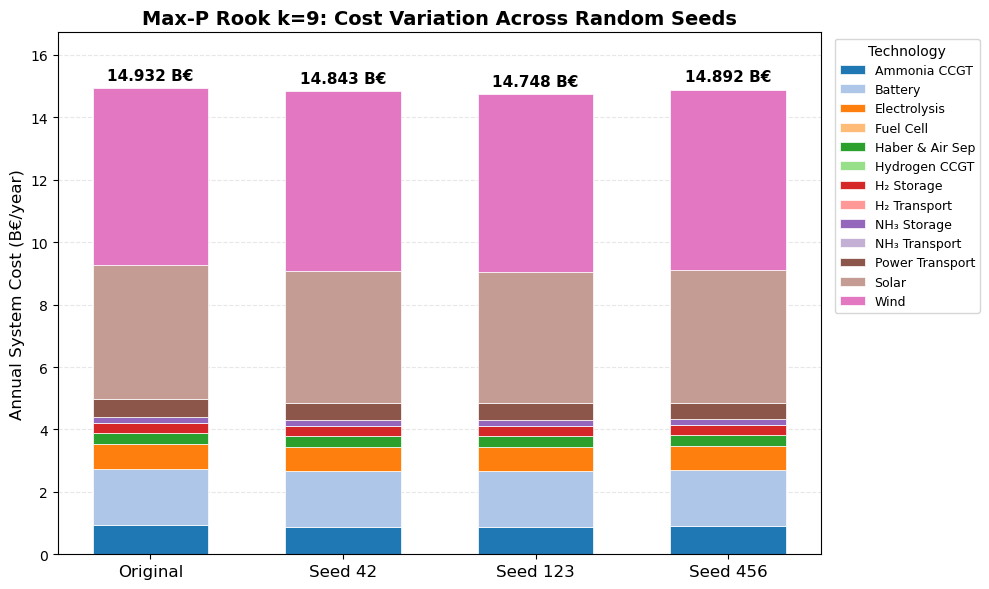


Total costs: {'Original': 14.932467484147725, 'Seed 42': 14.842711862871312, 'Seed 123': 14.747802513168882, 'Seed 456': 14.892429189800925}
Mean: 14.8539 B€, Spread: 0.1847 B€ (1.24%)


In [ ]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'

runs = {
    'Original': f'{base_dir}/MaxP_Rook_k9/weighted_percentile_timeseries/MaxP_Rook_weighted_k9_bidirectional.nc',
    'Seed 42':  f'{base_dir}/MaxP_Rook_k9_seed_42/weighted_percentile_timeseries/MaxP_Rook_k9_seed_42_weighted_bidirectional.nc',
    'Seed 123': f'{base_dir}/MaxP_Rook_k9_seed_123/weighted_percentile_timeseries/MaxP_Rook_k9_seed_123_weighted_bidirectional.nc',
    'Seed 456': f'{base_dir}/MaxP_Rook_k9_seed_456/weighted_percentile_timeseries/MaxP_Rook_k9_seed_456_weighted_bidirectional.nc',
}

tech_to_category = {
    'onshore_wind': 'Wind', 'solar_single_axis': 'Solar',
    'electrolyser': 'Electrolysis', 'haber_and_air_separation': 'Haber & Air Sep',
    'battery': 'Battery', 'fuel_cell': 'Fuel Cell',
    'compressed_hydrogen_storage': 'H₂ Storage', 'ammonia_storage': 'NH₃ Storage',
    'dc_transmission': 'Power Transport', 'hydrogen_pipeline': 'H₂ Transport',
    'ammonia_pipeline': 'NH₃ Transport', 'ammonia_ccgt': 'Ammonia CCGT',
    'hydrogen_ccgt': 'Hydrogen CCGT',
}

# --- Load costs ---
all_costs = {}
for label, path in runs.items():
    model = calliope.read_netcdf(path)
    cost_df = model.results['cost'].to_dataframe().reset_index()
    cost_df['tech'] = cost_df['loc_techs_cost'].str.split('::').str[-1].str.split(':').str[0]
    cost_df['category'] = cost_df['tech'].map(tech_to_category)
    all_costs[label] = cost_df.groupby('category')['cost'].sum()
    print(f"✓ {label}: {float(model.results.cost.sum())/1e6:.4f} B€")
    del model; gc.collect()

# Build DataFrame (B€)
all_categories = sorted(set().union(*[c.index for c in all_costs.values()]))
cost_matrix = pd.DataFrame(index=all_categories, columns=list(runs.keys()))
for label, costs in all_costs.items():
    for cat in all_categories:
        cost_matrix.loc[cat, label] = costs.get(cat, 0) / 1e6
cost_matrix = cost_matrix.fillna(0).astype(float)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
n = len(runs)
x = np.arange(n)
colors = plt.cm.tab20.colors
cat_colors = {cat: colors[i % len(colors)] for i, cat in enumerate(all_categories)}

bottom = np.zeros(n)
for cat in all_categories:
    values = cost_matrix.loc[cat].values
    ax.bar(x, values, bottom=bottom, label=cat, color=cat_colors[cat],
           edgecolor='white', linewidth=0.5, width=0.6)
    bottom += values

global_max = cost_matrix.sum().max() * 1.12
for i, label in enumerate(runs.keys()):
    total = cost_matrix[label].sum()
    ax.text(i, total + global_max * 0.01, f'{total:.3f} B€',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(list(runs.keys()), fontsize=12)
ax.set_ylabel('Annual System Cost (B€/year)', fontsize=12)
ax.set_ylim(0, global_max)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.set_title('Max-P Rook k=9: Cost Variation Across Random Seeds', fontsize=14, fontweight='bold')
ax.legend(title='Technology', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.savefig('4YP_Figures/maxp_stochasticity_cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary ---
totals = cost_matrix.sum()
spread = totals.max() - totals.min()
print(f"\nTotal costs: {totals.to_dict()}")
print(f"Mean: {totals.mean():.4f} B€, Spread: {spread:.4f} B€ ({spread/totals.mean()*100:.2f}%)")

✓ KMeans_Spatial_k20: 14.8008 B€
✓ KMeans_Spatial_k25: 14.3375 B€
✓ KMeans_Spatial_k30: 14.3403 B€


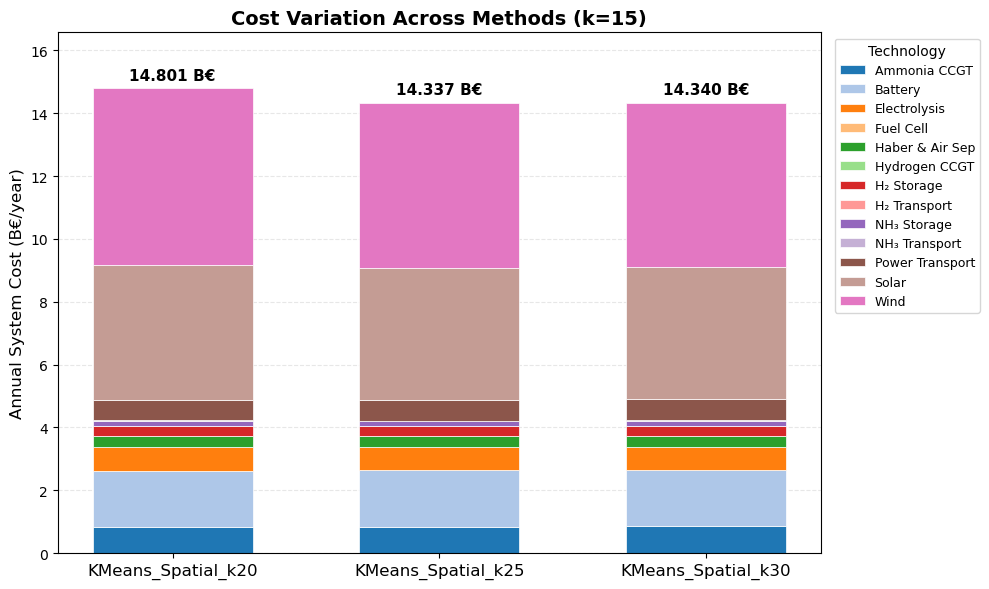


Total costs: {'KMeans_Spatial_k20': 14.800757553968925, 'KMeans_Spatial_k25': 14.337481856157037, 'KMeans_Spatial_k30': 14.34030663757955}
Mean: 14.4928 B€, Spread: 0.4633 B€ (3.20%)


In [1]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/'

runs = {
    'KMeans_Spatial_k20': f'{base_dir}/KMeans_Spatial/KMeans_Spatial_k15/weighted_percentile_timeseries/KMeans_Spatial_weighted_k15_bidirectional.nc',
    'KMeans_Spatial_k25': f'{base_dir}/KMeans_Spatial/KMeans_Spatial_k25/weighted_percentile_timeseries/KMeans_Spatial_weighted_k25_bidirectional.nc',
    'KMeans_Spatial_k30': f'{base_dir}/KMeans_Spatial/KMeans_Spatial_k30/weighted_percentile_timeseries/KMeans_Spatial_weighted_k30_bidirectional.nc',
}

tech_to_category = {
    'onshore_wind': 'Wind', 'solar_single_axis': 'Solar',
    'electrolyser': 'Electrolysis', 'haber_and_air_separation': 'Haber & Air Sep',
    'battery': 'Battery', 'fuel_cell': 'Fuel Cell',
    'compressed_hydrogen_storage': 'H₂ Storage', 'ammonia_storage': 'NH₃ Storage',
    'dc_transmission': 'Power Transport', 'hydrogen_pipeline': 'H₂ Transport',
    'ammonia_pipeline': 'NH₃ Transport', 'ammonia_ccgt': 'Ammonia CCGT',
    'hydrogen_ccgt': 'Hydrogen CCGT',
}

# --- Load costs ---
all_costs = {}
for label, path in runs.items():
    model = calliope.read_netcdf(path)
    cost_df = model.results['cost'].to_dataframe().reset_index()
    cost_df['tech'] = cost_df['loc_techs_cost'].str.split('::').str[-1].str.split(':').str[0]
    cost_df['category'] = cost_df['tech'].map(tech_to_category)
    all_costs[label] = cost_df.groupby('category')['cost'].sum()
    print(f"✓ {label}: {float(model.results.cost.sum())/1e6:.4f} B€")
    del model; gc.collect()

# Build DataFrame (B€)
all_categories = sorted(set().union(*[c.index for c in all_costs.values()]))
cost_matrix = pd.DataFrame(index=all_categories, columns=list(runs.keys()))
for label, costs in all_costs.items():
    for cat in all_categories:
        cost_matrix.loc[cat, label] = costs.get(cat, 0) / 1e6
cost_matrix = cost_matrix.fillna(0).astype(float)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
n = len(runs)
x = np.arange(n)
colors = plt.cm.tab20.colors
cat_colors = {cat: colors[i % len(colors)] for i, cat in enumerate(all_categories)}

bottom = np.zeros(n)
for cat in all_categories:
    values = cost_matrix.loc[cat].values
    ax.bar(x, values, bottom=bottom, label=cat, color=cat_colors[cat],
           edgecolor='white', linewidth=0.5, width=0.6)
    bottom += values

global_max = cost_matrix.sum().max() * 1.12
for i, label in enumerate(runs.keys()):
    total = cost_matrix[label].sum()
    ax.text(i, total + global_max * 0.01, f'{total:.3f} B€',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(list(runs.keys()), fontsize=12)
ax.set_ylabel('Annual System Cost (B€/year)', fontsize=12)
ax.set_ylim(0, global_max)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.set_title('Cost Variation Across Methods (k=15)', fontsize=14, fontweight='bold')
ax.legend(title='Technology', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.savefig('4YP_Figures/cost_comparison_across_methods_k15.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Summary ---
totals = cost_matrix.sum()
spread = totals.max() - totals.min()
print(f"\nTotal costs: {totals.to_dict()}")
print(f"Mean: {totals.mean():.4f} B€, Spread: {spread:.4f} B€ ({spread/totals.mean()*100:.2f}%)")

Reference KMeans_Spatial k=30 cost: 14.340306637579552 B€


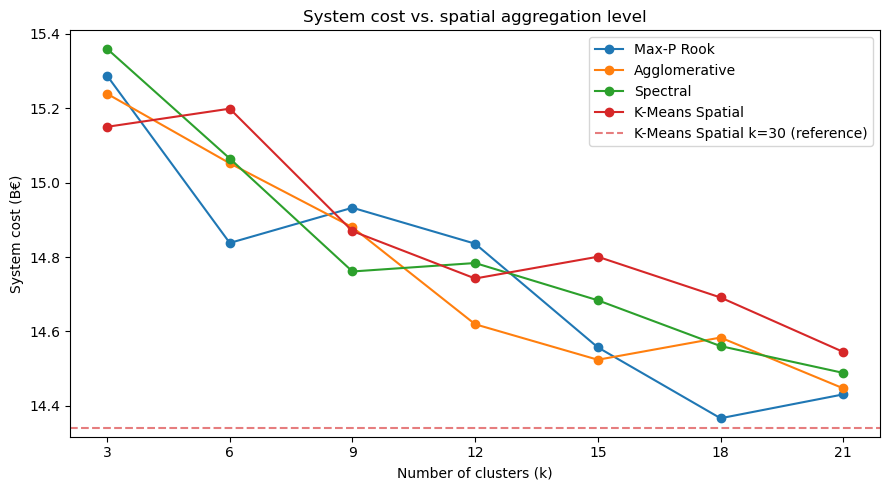

In [2]:

import os
import gc
import numpy as np
import calliope
import pandas as pd
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21]

# --- Load costs for the main 4x5 grid ---
records = []
for method in methods:
    for k in ks:
        path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue
        model = calliope.read_netcdf(path)
        cost = float(model.results.cost.sum())
        records.append({'method': method, 'k': k, 'cost': cost})
        del model
        gc.collect()

df = pd.DataFrame(records)

# --- Load k30 reference ---
ref_path30 = f"{base_dir}/KMeans_Spatial/KMeans_Spatial_k30/weighted_percentile_timeseries/KMeans_Spatial_weighted_k30_bidirectional.nc"
ref_model30 = calliope.read_netcdf(ref_path30)
ref_cost30 = float(ref_model30.results.cost.sum())
print(f"Reference KMeans_Spatial k=30 cost: {ref_cost30 / 1e6} B€")
del ref_model30
gc.collect()


# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

for method in methods:
    sub = df[df['method'] == method].sort_values('k')
    ax.plot(sub['k'], sub['cost'] / 1e6, marker='o', label=labels[method], color=colours[method])

ax.axhline(ref_cost30 / 1e6, color=colours['KMeans_Spatial'], linestyle='--', alpha=0.6, label='K-Means Spatial k=30 (reference)')

ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('System cost (B€)')
ax.set_xticks(ks)
ax.legend()
ax.set_title('System cost vs. spatial aggregation level')
plt.tight_layout()
plt.savefig('4YP_Figures/system_cost_vs_clusters.png', dpi=150)
plt.show()

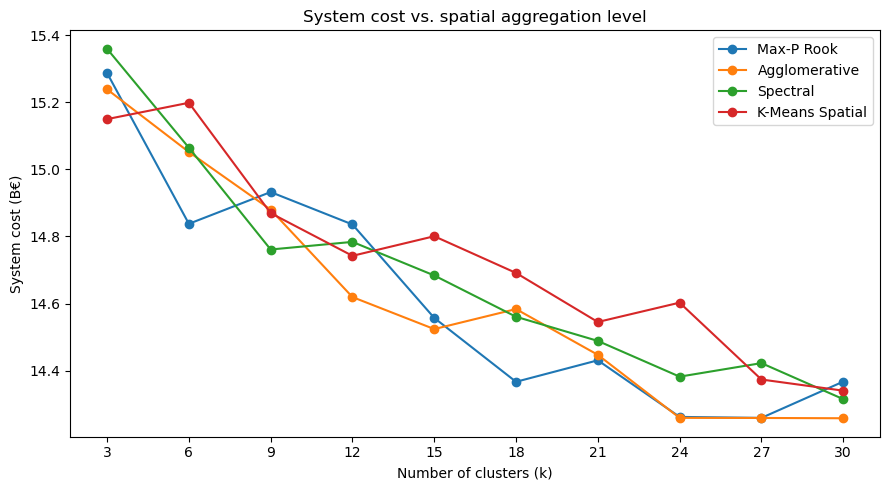

In [2]:
import os
import gc
import numpy as np
import calliope
import pandas as pd
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

# --- Load costs for the main 4x5 grid ---
records = []
for method in methods:
    for k in ks:
        path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue
        model = calliope.read_netcdf(path)
        cost = float(model.results.cost.sum())
        records.append({'method': method, 'k': k, 'cost': cost})
        del model
        gc.collect()

df = pd.DataFrame(records)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

for method in methods:
    sub = df[df['method'] == method].sort_values('k')
    ax.plot(sub['k'], sub['cost'] / 1e6, marker='o', label=labels[method], color=colours[method])

ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('System cost (B€)')
ax.set_xticks(ks)
ax.legend()
ax.set_title('System cost vs. spatial aggregation level')
plt.tight_layout()
plt.savefig('4YP_Figures/system_cost_vs_clusters_all30.png', dpi=150)
plt.show()

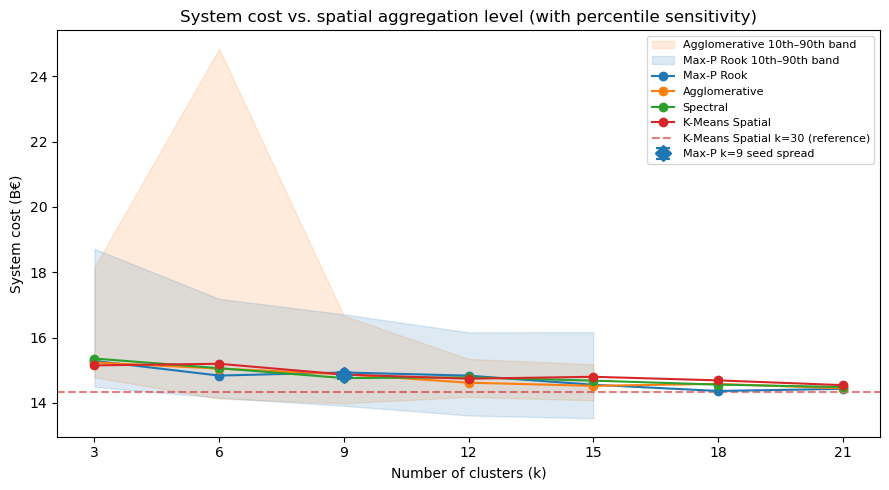


Method             k   10th (B€)  Weighted (B€)  90th (B€)  Band width
--------------------------------------------------------------------
Agglomerative      3      18.154         15.239     14.784     -3.370
Agglomerative      6      24.838         15.052     14.132    -10.706
Agglomerative      9      16.670         14.880     13.989     -2.681
Agglomerative     12      15.347         14.619     14.184     -1.163
Agglomerative     15      15.182         14.524     14.081     -1.101
MaxP_Rook          3      18.717         15.287     14.494     -4.223
MaxP_Rook          6      17.187         14.838     14.161     -3.027
MaxP_Rook          9      16.712         14.932     13.913     -2.799
MaxP_Rook         12      16.161         14.836     13.617     -2.544
MaxP_Rook         15      16.166         14.557     13.532     -2.634


In [1]:
import os
import gc
import numpy as np
import calliope
import pandas as pd
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

# --- 1. Load weighted costs (all methods, all k) ---
records = []
for method in methods:
    for k in ks:
        path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(path):
            continue
        model = calliope.read_netcdf(path)
        records.append({'method': method, 'k': k, 'cost': float(model.results.cost.sum())})
        del model; gc.collect()

df = pd.DataFrame(records)

# --- 2. Load 10th/90th costs for sensitivity bands ---
pct_ks = {'Agglomerative': [3, 6, 9, 12, 15], 'MaxP_Rook': [3, 6, 9, 12, 15]}
pct_records = []

for method, k_list in pct_ks.items():
    for k in k_list:
        for pct, folder in [('10th', '10_percentile_timeseries'), ('90th', '90_percentile_timeseries')]:
            path = f"{base_dir}/{method}/{method}_k{k}/{folder}/{method}_k{k}_{pct}_bidirectional.nc"
            if not os.path.exists(path):
                print(f"Missing: {path}")
                continue
            model = calliope.read_netcdf(path)
            pct_records.append({'method': method, 'k': k, 'percentile': pct,
                                'cost': float(model.results.cost.sum())})
            del model; gc.collect()

df_pct = pd.DataFrame(pct_records)

# --- 3. Load k30 reference ---
ref_path = f"{base_dir}/KMeans_Spatial/KMeans_Spatial_k30/weighted_percentile_timeseries/KMeans_Spatial_weighted_k30_bidirectional.nc"
ref_model = calliope.read_netcdf(ref_path)
ref_cost30 = float(ref_model.results.cost.sum())
del ref_model; gc.collect()

# --- 4. Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

# Shaded bands first (so lines draw on top)
for method in pct_ks:
    sub_10 = df_pct[(df_pct['method'] == method) & (df_pct['percentile'] == '10th')].sort_values('k')
    sub_90 = df_pct[(df_pct['method'] == method) & (df_pct['percentile'] == '90th')].sort_values('k')
    if len(sub_10) > 0 and len(sub_90) > 0:
        ax.fill_between(sub_10['k'].values, sub_10['cost'].values / 1e6, sub_90['cost'].values / 1e6,
                        color=colours[method], alpha=0.15, label=f'{labels[method]} 10th–90th band')

# Weighted lines
for method in methods:
    sub = df[df['method'] == method].sort_values('k')
    ax.plot(sub['k'], sub['cost'] / 1e6, marker='o', label=labels[method], color=colours[method], zorder=3)

# Reference line
ax.axhline(ref_cost30 / 1e6, color=colours['KMeans_Spatial'], linestyle='--', alpha=0.6,
           label='K-Means Spatial k=30 (reference)')

# MaxP stochasticity error bar at k=9
maxp_seed_costs = [14.932, 14.843, 14.748, 14.892]
mean_cost = np.mean(maxp_seed_costs)
ax.errorbar(9, mean_cost,
            yerr=[[mean_cost - min(maxp_seed_costs)], [max(maxp_seed_costs) - mean_cost]],
            fmt='D', color=colours['MaxP_Rook'], markersize=8, capsize=5, capthick=1.5,
            elinewidth=1.5, zorder=5, label=f'Max-P k=9 seed spread')

ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('System cost (B€)')
ax.set_xticks(ks)
ax.legend(fontsize=8)
ax.set_title('System cost vs. spatial aggregation level (with percentile sensitivity)')
plt.tight_layout()
plt.savefig('4YP_Figures/system_cost_sensitivity_bands.png', dpi=150)
plt.show()

# --- 5. Summary table ---
print(f"\n{'Method':<16} {'k':>3}  {'10th (B€)':>10} {'Weighted (B€)':>14} {'90th (B€)':>10} {'Band width':>11}")
print("-" * 68)
for method in pct_ks:
    for k in pct_ks[method]:
        w = df[(df['method'] == method) & (df['k'] == k)]['cost'].values
        p10 = df_pct[(df_pct['method'] == method) & (df_pct['k'] == k) & (df_pct['percentile'] == '10th')]['cost'].values
        p90 = df_pct[(df_pct['method'] == method) & (df_pct['k'] == k) & (df_pct['percentile'] == '90th')]['cost'].values
        if len(w) and len(p10) and len(p90):
            print(f"{method:<16} {k:>3}  {p10[0]/1e6:>10.3f} {w[0]/1e6:>14.3f} {p90[0]/1e6:>10.3f} {(p90[0]-p10[0])/1e6:>10.3f}")

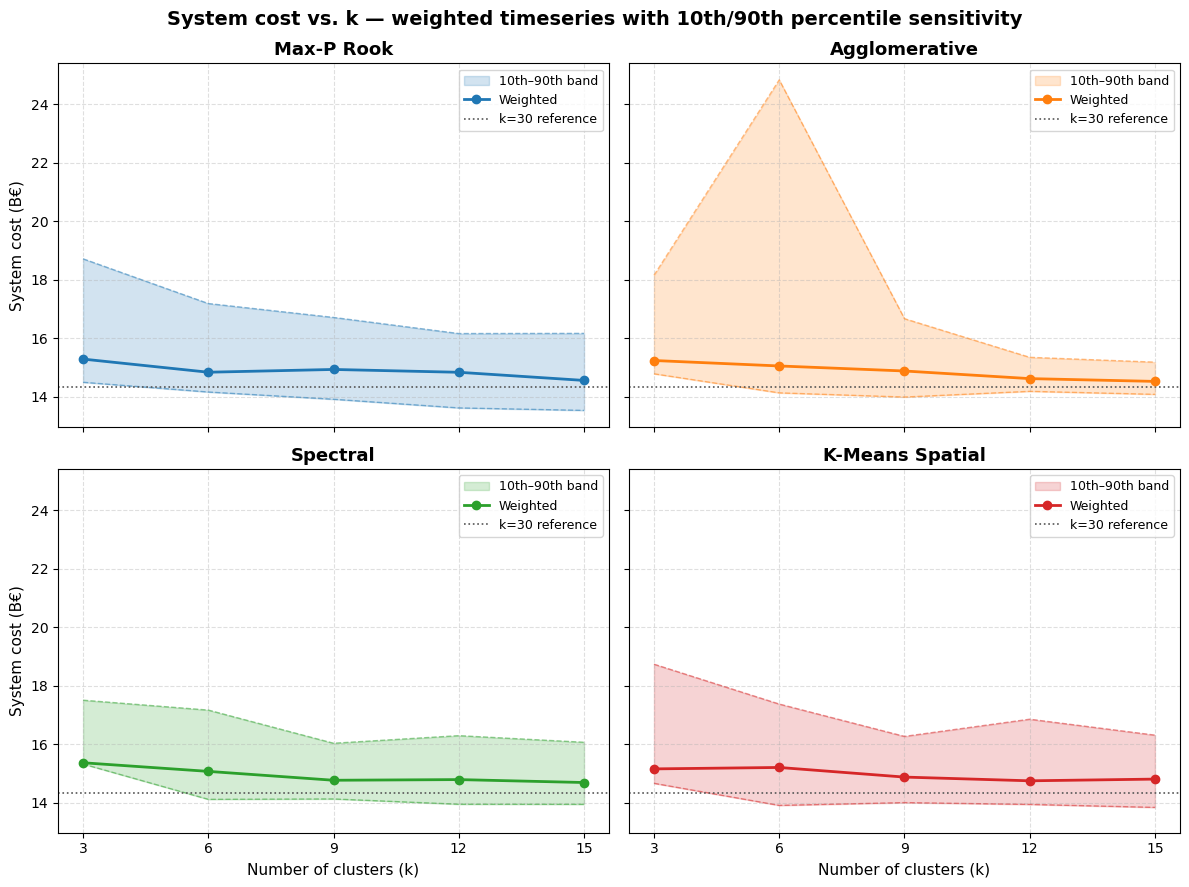

In [ ]:
# Sensitivity Comparison

import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir  = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods   = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks_main   = [3, 6, 9, 12, 15]
ks_sens   = [3, 6, 9, 12, 15]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e',
           'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P', 'Agglomerative': 'Agglomerative',
           'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means'}

# ── Load main (weighted) costs ────────────────────────────────────────────
records = []
for method in methods:
    for k in ks_main:
        path = (f"{base_dir}/{method}/{method}_k{k}/"
                f"weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc")
        if not os.path.exists(path):
            continue
        model = calliope.read_netcdf(path)
        records.append({'method': method, 'k': k, 'cost': float(model.results.cost.sum())})
        del model; gc.collect()
df = pd.DataFrame(records)

# ── Load 10th / 90th costs ─────────────────────────────────────────────────
pct_records = []
for method in methods:
    for k in ks_sens:
        for pct, folder in [('10th', '10_percentile_timeseries'),
                             ('90th', '90_percentile_timeseries')]:
            path = (f"{base_dir}/{method}/{method}_k{k}/"
                    f"{folder}/{method}_k{k}_{pct}_bidirectional.nc")
            if not os.path.exists(path):
                continue
            model = calliope.read_netcdf(path)
            pct_records.append({'method': method, 'k': k, 'pct': pct,
                                 'cost': float(model.results.cost.sum())})
            del model; gc.collect()
df_pct = pd.DataFrame(pct_records)

# ── 2×2 plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)

for ax, method in zip(axes.flat, methods):
    colour = colours[method]

    # Sensitivity band (k=3–15)
    sub_10 = df_pct[(df_pct['method'] == method) & (df_pct['pct'] == '10th')].sort_values('k')
    sub_90 = df_pct[(df_pct['method'] == method) & (df_pct['pct'] == '90th')].sort_values('k')
    if len(sub_10) and len(sub_90):
        ax.fill_between(sub_10['k'], sub_10['cost'] / 1e6, sub_90['cost'] / 1e6,
                        color=colour, alpha=0.2, label='10th–90th band')
        ax.plot(sub_10['k'], sub_10['cost'] / 1e6, linestyle='--',
                linewidth=1.0, color=colour, alpha=0.5)
        ax.plot(sub_90['k'], sub_90['cost'] / 1e6, linestyle='--',
                linewidth=1.0, color=colour, alpha=0.5)

    # Main weighted line
    sub = df[df['method'] == method].sort_values('k')
    ax.plot(sub['k'], sub['cost'] / 1e6, marker='o', linewidth=2, markersize=6,
            color=colour, label='Weighted', zorder=3)

    ax.set_title(labels[method], fontsize=13, fontweight='bold')
    ax.set_xticks(ks_main)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=9, loc='upper right')

for ax in axes[1]:
    ax.set_xlabel('Number of clusters (k)', fontsize=11)
for ax in axes[:, 0]:
    ax.set_ylabel('System cost (B€)', fontsize=11)

fig.suptitle('System cost vs. k — weighted timeseries with 10th/90th percentile sensitivity',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('4YP_Figures/system_cost_2x2_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()

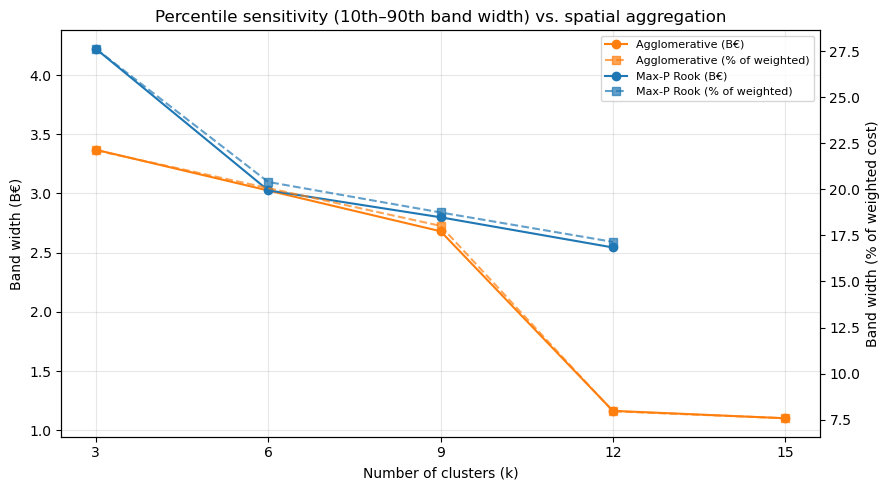

In [3]:
# --- Percentile band width vs k (twin axis: absolute + relative) ---
# Requires df, df_pct, pct_ks from the preceding cell

import numpy as np
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

lines = []
for method in pct_ks:
    bw_abs, bw_pct, k_vals = [], [], []
    for k in pct_ks[method]:
        p10 = df_pct[(df_pct['method'] == method) & (df_pct['k'] == k) & (df_pct['percentile'] == '10th')]['cost'].values
        p90 = df_pct[(df_pct['method'] == method) & (df_pct['k'] == k) & (df_pct['percentile'] == '90th')]['cost'].values
        w   = df[(df['method'] == method) & (df['k'] == k)]['cost'].values
        if len(p10) and len(p90) and len(w):
            k_vals.append(k)
            bw_abs.append(abs((p90[0] - p10[0]) / 1e6))
            bw_pct.append(abs((p90[0] - p10[0]) / w[0] * 100))

    l1, = ax1.plot(k_vals, bw_abs, marker='o', color=colours[method], label=f'{labels[method]} (B€)')
    l2, = ax2.plot(k_vals, bw_pct, marker='s', linestyle='--', color=colours[method], alpha=0.7,
                   label=f'{labels[method]} (% of weighted)')
    lines.extend([l1, l2])

ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Band width (B€)')
ax2.set_ylabel('Band width (% of weighted cost)')
ax1.set_xticks(sorted(set(k for ks in pct_ks.values() for k in ks)))
ax1.grid(True, alpha=0.3)
ax1.legend(handles=lines, fontsize=8, loc='upper right')
ax1.set_title('Percentile sensitivity (10th–90th band width) vs. spatial aggregation')
plt.tight_layout()
plt.savefig('4YP_Figures/percentile_band_width_vs_k.png', dpi=150)
plt.show()

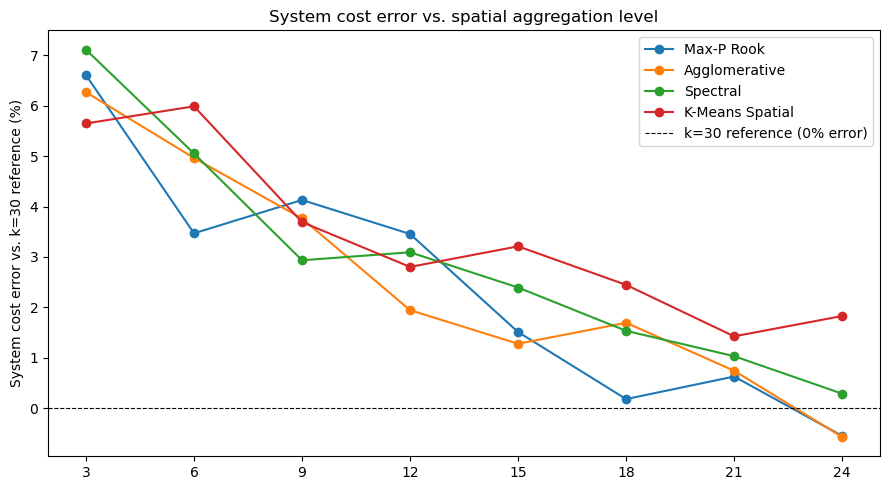

In [14]:
import os
import gc
import numpy as np
import calliope
import pandas as pd
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24]

# --- Load costs for the main 4x5 grid ---
records = []
for method in methods:
    for k in ks:
        path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue
        model = calliope.read_netcdf(path)
        cost = float(model.results.cost.sum())
        records.append({'method': method, 'k': k, 'cost': cost})
        del model
        gc.collect()

df = pd.DataFrame(records)

# --- Load k30 reference ---
ref_path = f"{base_dir}/KMeans_Spatial/KMeans_Spatial_k30/weighted_percentile_timeseries/KMeans_Spatial_weighted_k30_bidirectional.nc"
ref_model = calliope.read_netcdf(ref_path)
ref_cost = float(ref_model.results.cost.sum())
del ref_model
gc.collect()



# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

df['pct_error'] = (df['cost'] - ref_cost) / ref_cost * 100

for method in methods:
    sub = df[df['method'] == method].sort_values('k')
    ax.plot(sub['k'], sub['pct_error'], marker='o', label=labels[method], color=colours[method])

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, label='k=30 reference (0% error)')
ax.set_ylabel('System cost error vs. k=30 reference (%)')
ax.set_xticks(ks)
ax.legend()
ax.set_title('System cost error vs. spatial aggregation level')
plt.tight_layout()
# plt.savefig('4YP_Figures/system_cost_vs_clusters.png', dpi=150)
plt.show()

✓ MaxP_Rook k=3
✓ MaxP_Rook k=6
✓ MaxP_Rook k=9
✓ MaxP_Rook k=12
✓ MaxP_Rook k=15
✓ MaxP_Rook k=18
✓ MaxP_Rook k=21
✓ MaxP_Rook k=24
✓ MaxP_Rook k=27
✓ MaxP_Rook k=30
✓ Agglomerative k=3
✓ Agglomerative k=6
✓ Agglomerative k=9
✓ Agglomerative k=12
✓ Agglomerative k=15
✓ Agglomerative k=18
✓ Agglomerative k=21
✓ Agglomerative k=24
✓ Agglomerative k=27
✓ Agglomerative k=30
✓ Spectral k=3
✓ Spectral k=6
✓ Spectral k=9
✓ Spectral k=12
✓ Spectral k=15
✓ Spectral k=18
✓ Spectral k=21
✓ Spectral k=24
✓ Spectral k=27
✓ Spectral k=30
✓ KMeans_Spatial k=3
✓ KMeans_Spatial k=6
✓ KMeans_Spatial k=9
✓ KMeans_Spatial k=12
✓ KMeans_Spatial k=15
✓ KMeans_Spatial k=18
✓ KMeans_Spatial k=21
✓ KMeans_Spatial k=24
✓ KMeans_Spatial k=27
✓ KMeans_Spatial k=30


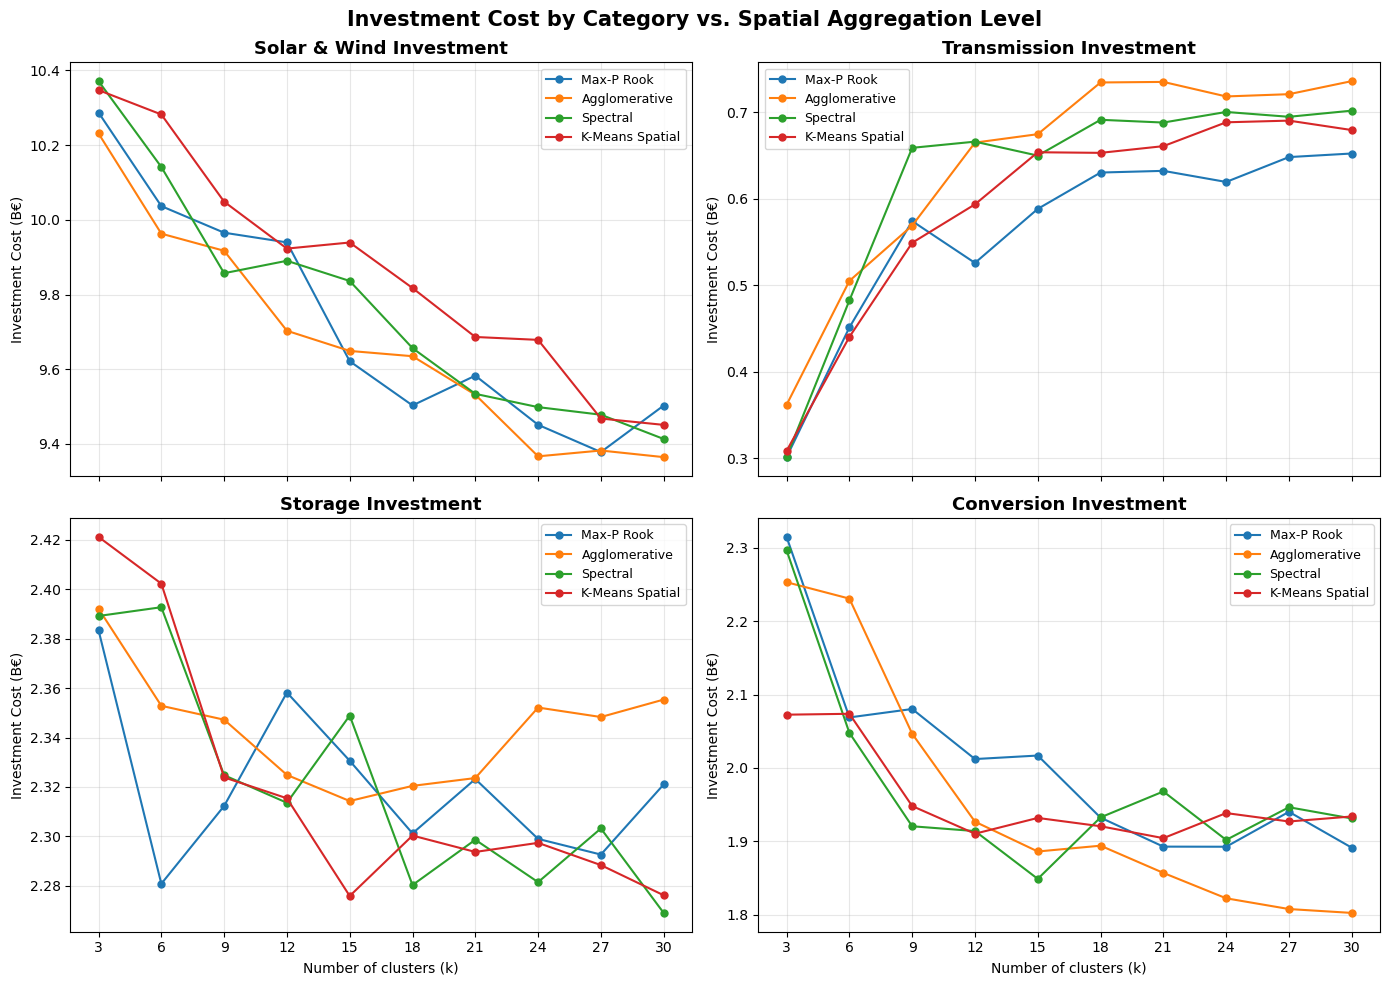

In [2]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

# --- Technology groupings ---
solar_wind_techs = ['solar_single_axis', 'onshore_wind', 'offshore_wind']
transmission_techs = ['dc_transmission', 'hydrogen_pipeline', 'ammonia_pipeline', 'methane_pipeline']
storage_techs = ['battery', 'compressed_hydrogen_storage', 'cavern_hydrogen_storage', 'ammonia_storage']
conversion_techs = ['fuel_cell', 'electrolyser', 'ammonia_ccgt', 'hydrogen_ccgt', 'haber_and_air_separation']

# --- Load investment costs for all methods and k values ---
all_records = {m: [] for m in methods}

for method in methods:
    for k in ks:
        nc_path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(nc_path):
            print(f"Missing: {nc_path}")
            continue

        model = calliope.read_netcdf(nc_path)

        cost_invest = model.results['cost_investment'].to_dataframe().reset_index()
        cost_invest['tech'] = cost_invest['loc_techs_investment_cost'].str.split('::').str[-1].str.split(':').str[0]
        tech_investment = cost_invest.groupby('tech')['cost_investment'].sum()

        row = {'k': k}
        row['solar_wind'] = sum(tech_investment.get(t, 0) for t in solar_wind_techs)
        row['transmission'] = sum(tech_investment.get(t, 0) for t in transmission_techs)
        row['storage'] = sum(tech_investment.get(t, 0) for t in storage_techs)
        row['conversion'] = sum(tech_investment.get(t, 0) for t in conversion_techs)

        all_records[method].append(row)
        print(f"✓ {method} k={k}")
        del model
        gc.collect()

# --- Plot ---
colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

groups = [
    (axes[0, 0], 'solar_wind', 'Solar & Wind Investment'),
    (axes[0, 1], 'transmission', 'Transmission Investment'),
    (axes[1, 0], 'storage', 'Storage Investment'),
    (axes[1, 1], 'conversion', 'Conversion Investment'),
]

for ax, col, title in groups:
    for method in methods:
        if all_records[method]:
            df_m = pd.DataFrame(all_records[method]).sort_values('k')
            ax.plot(df_m['k'], df_m[col] / 1e6, marker='o', markersize=5,
                    color=colours[method], label=labels[method])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Investment Cost (B€)')
    ax.set_xticks(ks)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

for ax in axes[1, :]:
    ax.set_xlabel('Number of clusters (k)')

plt.suptitle('Investment Cost by Category vs. Spatial Aggregation Level', fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig('4YP_Figures/investment_by_category_vs_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

✓ MaxP_Rook k=3
✓ MaxP_Rook k=6
✓ MaxP_Rook k=9
✓ MaxP_Rook k=12
✓ MaxP_Rook k=15
✓ Agglomerative k=3
✓ Agglomerative k=6
✓ Agglomerative k=9
✓ Agglomerative k=12
✓ Agglomerative k=15
✓ Spectral k=3
✓ Spectral k=6
✓ Spectral k=9
✓ Spectral k=12
✓ Spectral k=15
✓ KMeans_Spatial k=3
✓ KMeans_Spatial k=6
✓ KMeans_Spatial k=9
✓ KMeans_Spatial k=12
✓ KMeans_Spatial k=15


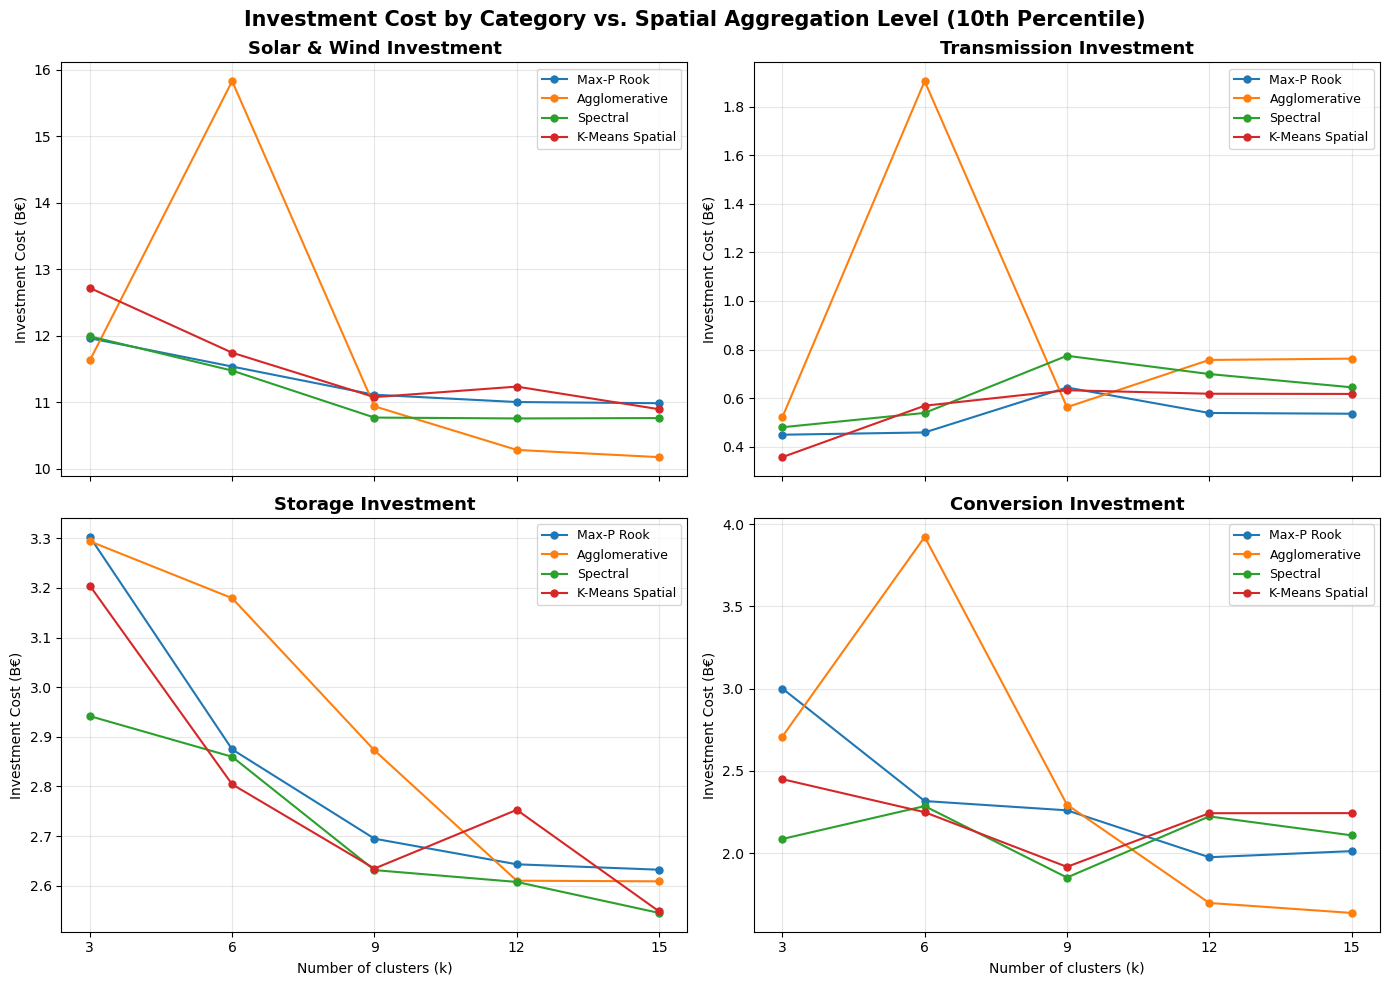

In [2]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15]

# --- Technology groupings ---
solar_wind_techs = ['solar_single_axis', 'onshore_wind', 'offshore_wind']
transmission_techs = ['dc_transmission', 'hydrogen_pipeline', 'ammonia_pipeline', 'methane_pipeline']
storage_techs = ['battery', 'compressed_hydrogen_storage', 'cavern_hydrogen_storage', 'ammonia_storage']
conversion_techs = ['fuel_cell', 'electrolyser', 'ammonia_ccgt', 'hydrogen_ccgt', 'haber_and_air_separation']

# --- Load investment costs for all methods and k values ---
all_records = {m: [] for m in methods}

for method in methods:
    for k in ks:
        nc_path = f"{base_dir}/{method}/{method}_k{k}/10_percentile_timeseries/{method}_k{k}_10th_bidirectional.nc"
        if not os.path.exists(nc_path):
            print(f"Missing: {nc_path}")
            continue

        model = calliope.read_netcdf(nc_path)

        cost_invest = model.results['cost_investment'].to_dataframe().reset_index()
        cost_invest['tech'] = cost_invest['loc_techs_investment_cost'].str.split('::').str[-1].str.split(':').str[0]
        tech_investment = cost_invest.groupby('tech')['cost_investment'].sum()

        row = {'k': k}
        row['solar_wind'] = sum(tech_investment.get(t, 0) for t in solar_wind_techs)
        row['transmission'] = sum(tech_investment.get(t, 0) for t in transmission_techs)
        row['storage'] = sum(tech_investment.get(t, 0) for t in storage_techs)
        row['conversion'] = sum(tech_investment.get(t, 0) for t in conversion_techs)

        all_records[method].append(row)
        print(f"✓ {method} k={k}")
        del model
        gc.collect()

# --- Plot ---
colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

groups = [
    (axes[0, 0], 'solar_wind', 'Solar & Wind Investment'),
    (axes[0, 1], 'transmission', 'Transmission Investment'),
    (axes[1, 0], 'storage', 'Storage Investment'),
    (axes[1, 1], 'conversion', 'Conversion Investment'),
]

for ax, col, title in groups:
    for method in methods:
        if all_records[method]:
            df_m = pd.DataFrame(all_records[method]).sort_values('k')
            ax.plot(df_m['k'], df_m[col] / 1e6, marker='o', markersize=5,
                    color=colours[method], label=labels[method])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Investment Cost (B€)')
    ax.set_xticks(ks)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

for ax in axes[1, :]:
    ax.set_xlabel('Number of clusters (k)')

plt.suptitle('Investment Cost by Category vs. Spatial Aggregation Level (10th Percentile)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('4YP_Figures/investment_by_category_vs_clusters_10th.png', dpi=150, bbox_inches='tight')
plt.show()

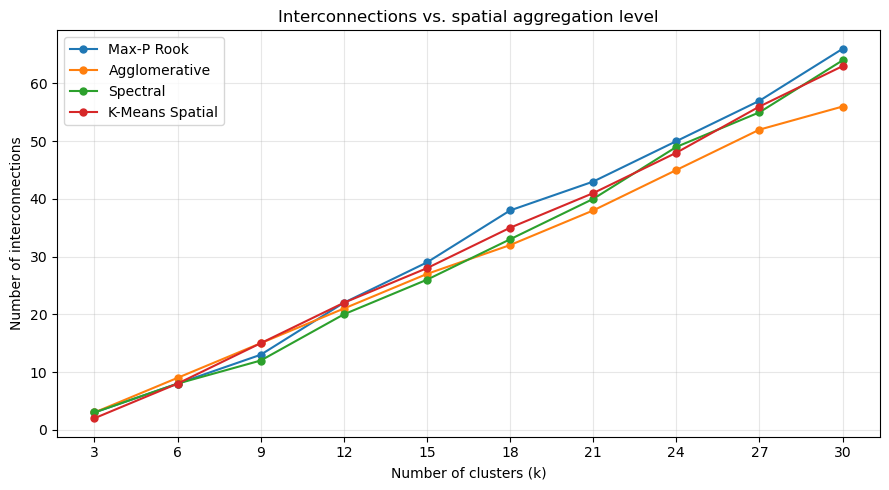

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

fig, ax = plt.subplots(figsize=(9, 5))

for method in methods:
    counts = []
    for k in ks:
        links_path = f"{base_dir}/{method}/{method}_k{k}/reduced_links.csv"
        if not os.path.exists(links_path):
            print(f"Missing: {links_path}")
            continue
        n_links = len(pd.read_csv(links_path))
        counts.append({'k': k, 'links': n_links})
    if counts:
        df_m = pd.DataFrame(counts).sort_values('k')
        ax.plot(df_m['k'], df_m['links'], marker='o', markersize=5,
                color=colours[method], label=labels[method])

ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Number of interconnections')
ax.set_xticks(ks)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title('Interconnections vs. spatial aggregation level')
plt.tight_layout()
# plt.savefig('4YP_Figures/interconnections_vs_clusters.png', dpi=150)
plt.show()

Method                   A (B€)        λ       R²  k* (1%)
----------------------------------------------------------
MaxP_Rook                  1.33   0.1197   0.8618     18.6
Agglomerative              1.35   0.1191   0.9380     18.8
Spectral                   1.38   0.1066   0.9662     21.2
KMeans_Spatial             1.05   0.0646   0.8887     30.8


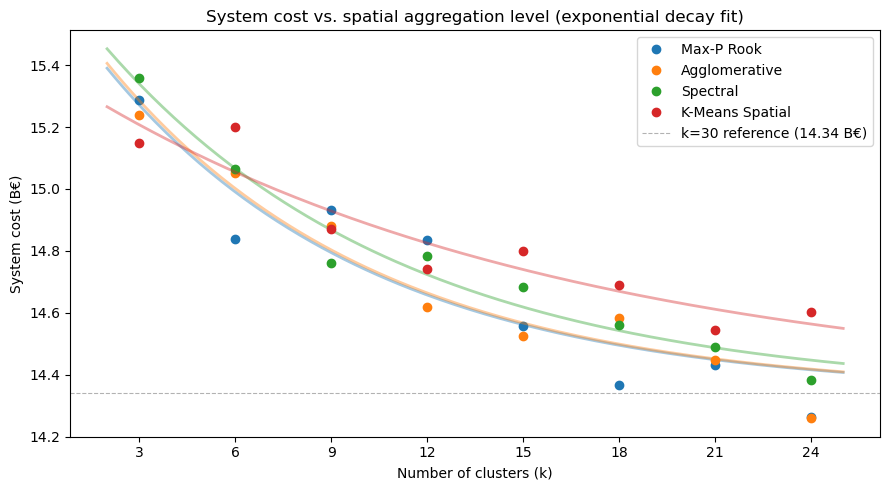

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Exponential decay fit: C(k) = C_inf + A * exp(-lambda * k) ---
# C_inf fixed to ref_cost30 (already in kernel)

def decay_model(k, A, lam):
    return ref_cost + A * np.exp(-lam * k)

fig, ax = plt.subplots(figsize=(9, 5))
k_smooth = np.linspace(2, 25, 200)

print(f"{'Method':<20} {'A (B€)':>10} {'λ':>8} {'R²':>8} {'k* (1%)':>8}")
print("-" * 58)

for method in methods:
    sub = df[df['method'] == method].sort_values('k')
    k_data = sub['k'].values.astype(float)
    c_data = sub['cost'].values.astype(float)

    # Initial guesses
    A0 = c_data.max() - ref_cost
    p0 = [A0, 0.1]

    try:
        popt, pcov = curve_fit(decay_model, k_data, c_data, p0=p0, maxfev=5000)
        A_fit, lam_fit = popt

        # R²
        c_pred = decay_model(k_data, *popt)
        ss_res = np.sum((c_data - c_pred) ** 2)
        ss_tot = np.sum((c_data - np.mean(c_data)) ** 2)
        r2 = 1 - ss_res / ss_tot

        # k* where cost is within 1% of C_inf
        # C(k*) = 1.01 * C_inf => A * exp(-λk*) = 0.01 * C_inf => k* = -ln(0.01*C_inf/A) / λ
        if A_fit > 0 and lam_fit > 0:
            ratio = 0.01 * ref_cost / A_fit
            k_star = -np.log(ratio) / lam_fit if ratio > 0 and ratio < 1 else float('nan')
        else:
            k_star = float('nan')

        print(f"{method:<20} {A_fit/1e6:>10.2f} {lam_fit:>8.4f} {r2:>8.4f} {k_star:>8.1f}")

        # Plot fitted curve
        ax.plot(k_smooth, decay_model(k_smooth, *popt) / 1e6,
                color=colours[method], alpha=0.4, linewidth=2)
    except RuntimeError:
        print(f"{method:<20} {'FIT FAILED':>38}")

    # Plot data points
    ax.plot(k_data, c_data / 1e6, marker='o', linestyle='none',
            color=colours[method], label=labels[method], markersize=6)

ax.axhline(ref_cost / 1e6, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label=f'k=30 reference ({ref_cost/1e6:.2f} B€)')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('System cost (B€)')
ax.set_xticks(ks)
ax.legend()
ax.set_title('System cost vs. spatial aggregation level (exponential decay fit)')
plt.tight_layout()
plt.savefig('4YP_Figures/system_cost_decay_fit.png', dpi=150)
plt.show()

Method                   A (B€)        λ       R²  k* (1%)    p(A)    p(λ)
--------------------------------------------------------------------------


NameError: name 'methods' is not defined

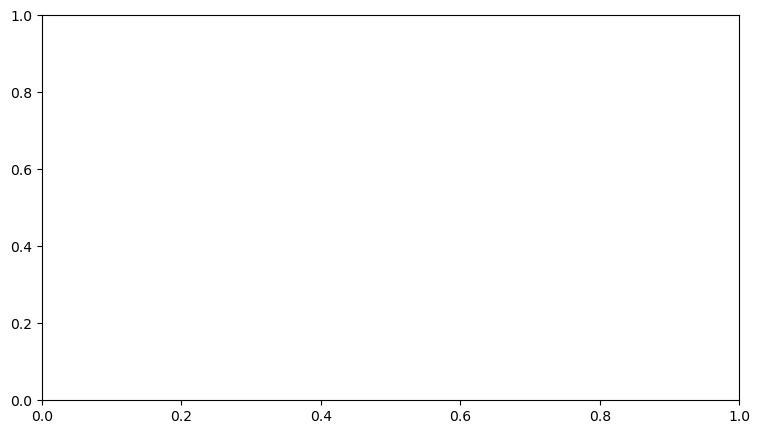

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats

# --- Exponential decay fit: C(k) = C_inf + A * exp(-lambda * k) ---
# C_inf fixed to ref_cost30 (already in kernel)

def decay_model(k, A, lam):
    return ref_cost + A * np.exp(-lam * k)

fig, ax = plt.subplots(figsize=(9, 5))
k_smooth = np.linspace(2, 25, 200)

print(f"{'Method':<20} {'A (B€)':>10} {'λ':>8} {'R²':>8} {'k* (1%)':>8} {'p(A)':>7} {'p(λ)':>7}")
print("-" * 74)

for method in methods:
    sub = df[df['method'] == method].sort_values('k')
    k_data = sub['k'].values.astype(float)
    c_data = sub['cost'].values.astype(float)

    # Initial guesses
    A0 = c_data.max() - ref_cost
    p0 = [A0, 0.1]

    try:
        popt, pcov = curve_fit(decay_model, k_data, c_data, p0=p0, maxfev=5000)
        A_fit, lam_fit = popt

        # R²
        c_pred = decay_model(k_data, *popt)
        ss_res = np.sum((c_data - c_pred) ** 2)
        ss_tot = np.sum((c_data - np.mean(c_data)) ** 2)
        r2 = 1 - ss_res / ss_tot

        # p-values for A and lambda via t-test (df = n_points - n_params)
        n_pts = len(k_data)
        perr = np.sqrt(np.diag(pcov))
        t_stats = popt / perr
        p_vals = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n_pts - 2))
        p_A, p_lam = p_vals

        # k* where cost is within 1% of C_inf
        if A_fit > 0 and lam_fit > 0:
            ratio = 0.01 * ref_cost / A_fit
            k_star = -np.log(ratio) / lam_fit if ratio > 0 and ratio < 1 else float('nan')
        else:
            k_star = float('nan')

        print(f"{method:<20} {A_fit/1e6:>10.2f} {lam_fit:>8.4f} {r2:>8.4f} {k_star:>8.1f} {p_A:>7.4f} {p_lam:>7.4f}")

        # Plot fitted curve
        ax.plot(k_smooth, decay_model(k_smooth, *popt) / 1e6,
                color=colours[method], alpha=0.4, linewidth=2)
    except RuntimeError:
        print(f"{method:<20} {'FIT FAILED':>38}")

    # Plot data points
    ax.plot(k_data, c_data / 1e6, marker='o', linestyle='none',
            color=colours[method], label=labels[method], markersize=6)

ax.axhline(ref_cost30 / 1e6, color='grey', linestyle='--', linewidth=0.8, alpha=0.6, label=f'k=30 reference ({ref_cost30/1e6:.2f} B€)')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('System cost (B€)')
ax.set_xticks(ks)
ax.legend()
ax.set_title('System cost vs. spatial aggregation level (exponential decay fit)')
plt.tight_layout()
plt.savefig('4YP_Figures/system_cost_decay_fit.png', dpi=150)
plt.show()

Method                   A (B€)        λ  C∞ (B€)       R²  k* (1%)    p(A)    p(λ)   p(C∞)
-------------------------------------------------------------------------------------------
MaxP_Rook                  1.41   0.0751    14.11   0.9073     30.7  0.0001  0.0742  0.0000
Agglomerative              1.48   0.0681    14.04   0.9713     34.6  0.0000  0.0086  0.0000
Spectral                   1.39   0.0905    14.27   0.9717     25.2  0.0000  0.0028  0.0000
KMeans_Spatial             1.88   0.0237    13.43   0.9260    111.4  0.2405  0.4334  0.0001


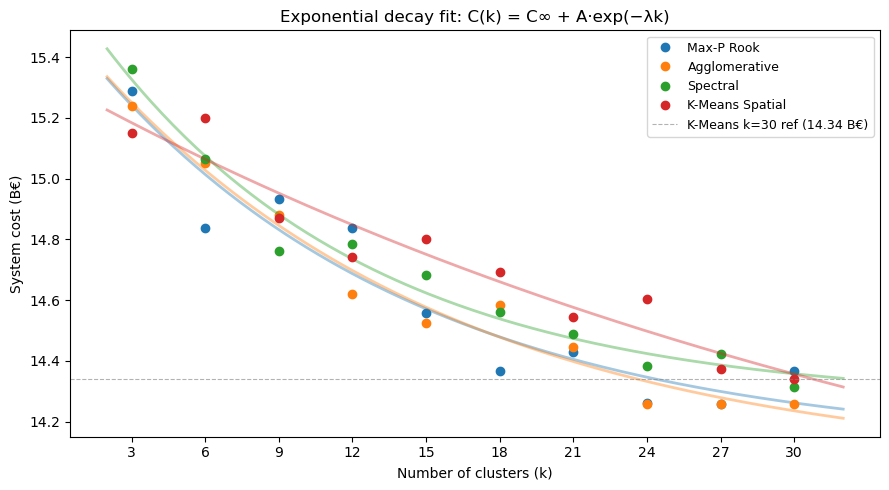

In [1]:
import os
import gc
import numpy as np
import calliope
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats

# ── 1. Load all costs ───────────────────────────────────────────────────
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24, 27, 30]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

records = []
for method in methods:
    for k in ks:
        path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue
        model = calliope.read_netcdf(path)
        records.append({'method': method, 'k': k, 'cost': float(model.results.cost.sum())})
        del model; gc.collect()

df = pd.DataFrame(records)

# k=30 reference (for plotting only, not used in fit)
ref_path = f"{base_dir}/KMeans_Spatial/KMeans_Spatial_k30/weighted_percentile_timeseries/KMeans_Spatial_weighted_k30_bidirectional.nc"
ref_model = calliope.read_netcdf(ref_path)
ref_cost = float(ref_model.results.cost.sum())
del ref_model; gc.collect()

# ── 2. Three-parameter decay fit: C(k) = C_inf + A * exp(-λk) ──────────
def decay_model_3p(k, A, lam, C_inf):
    return C_inf + A * np.exp(-lam * k)

fig, ax = plt.subplots(figsize=(9, 5))
k_smooth = np.linspace(2, 32, 200)

header = f"{'Method':<20} {'A (B€)':>10} {'λ':>8} {'C∞ (B€)':>8} {'R²':>8} {'k* (1%)':>8} {'p(A)':>7} {'p(λ)':>7} {'p(C∞)':>7}"
print(header)
print("-" * len(header))

for method in methods:
    sub = df[df['method'] == method].sort_values('k')
    k_data = sub['k'].values.astype(float)
    c_data = sub['cost'].values.astype(float)

    # Initial guesses: A ≈ range, λ ≈ 0.1, C_inf ≈ min cost
    p0 = [c_data.max() - c_data.min(), 0.1, c_data.min()]

    try:
        popt, pcov = curve_fit(decay_model_3p, k_data, c_data, p0=p0, maxfev=10000)
        A_fit, lam_fit, C_inf_fit = popt

        # R²
        c_pred = decay_model_3p(k_data, *popt)
        ss_res = np.sum((c_data - c_pred) ** 2)
        ss_tot = np.sum((c_data - np.mean(c_data)) ** 2)
        r2 = 1 - ss_res / ss_tot

        # p-values (t-test, df = n_points - 3 parameters)
        n_pts = len(k_data)
        perr = np.sqrt(np.diag(pcov))
        t_stats = popt / perr
        p_vals = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n_pts - 3))
        p_A, p_lam, p_Cinf = p_vals

        # k* where cost is within 1% of C_inf
        if A_fit > 0 and lam_fit > 0:
            ratio = 0.01 * C_inf_fit / A_fit
            k_star = -np.log(ratio) / lam_fit if 0 < ratio < 1 else float('nan')
        else:
            k_star = float('nan')

        print(f"{method:<20} {A_fit/1e6:>10.2f} {lam_fit:>8.4f} {C_inf_fit/1e6:>8.2f} {r2:>8.4f} {k_star:>8.1f} {p_A:>7.4f} {p_lam:>7.4f} {p_Cinf:>7.4f}")

        # Fitted curve
        ax.plot(k_smooth, decay_model_3p(k_smooth, *popt) / 1e6,
                color=colours[method], alpha=0.4, linewidth=2)
    except RuntimeError:
        print(f"{method:<20} {'FIT FAILED':>60}")

    # Data points
    ax.plot(k_data, c_data / 1e6, marker='o', linestyle='none',
            color=colours[method], label=labels[method], markersize=6)

ax.axhline(ref_cost / 1e6, color='grey', linestyle='--', linewidth=0.8, alpha=0.6,
           label=f'K-Means k=30 ref ({ref_cost/1e6:.2f} B€)')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('System cost (B€)')
ax.set_xticks(ks)
ax.legend(fontsize=9)
ax.set_title('Exponential decay fit: C(k) = C∞ + A·exp(−λk)')
plt.tight_layout()
# plt.savefig('4YP_Figures/system_cost_decay_fit_3p.png', dpi=150)
plt.show()

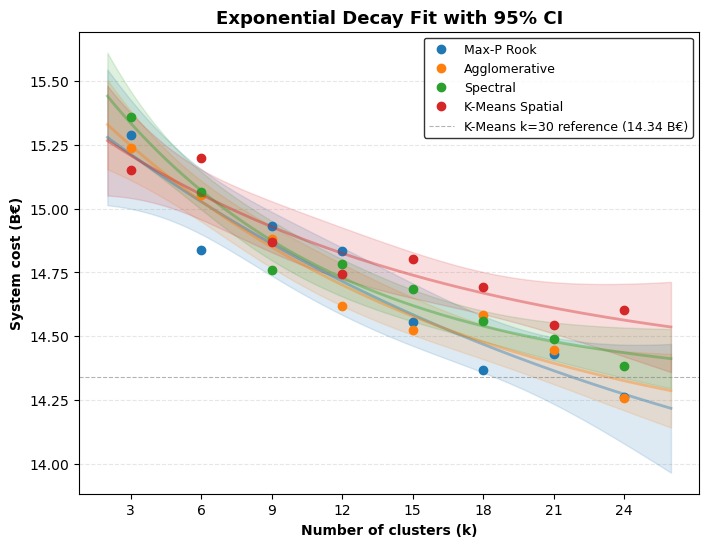

         Method       R2   lambda  C_inf_BE
     Max-P Rook 0.908022 0.038912 13.531479
  Agglomerative 0.960823 0.064118 14.002513
       Spectral 0.966528 0.098753 14.306568
K-Means Spatial 0.888727 0.064671 14.340522


In [1]:
import os, gc, numpy as np, calliope, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ── Config ──
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

# ── Load costs ──
records = []
for method in methods:
    for k in ks:
        path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue
        model = calliope.read_netcdf(path)
        records.append({'method': method, 'k': k, 'cost': float(model.results.cost.sum())})
        del model; gc.collect()

df = pd.DataFrame(records)

ref_path = f"{base_dir}/KMeans_Spatial/KMeans_Spatial_k30/weighted_percentile_timeseries/KMeans_Spatial_weighted_k30_bidirectional.nc"
ref_model = calliope.read_netcdf(ref_path)
ref_cost = float(ref_model.results.cost.sum())
del ref_model; gc.collect()

# ── Decay model & Jacobian ──
def decay_model_3p(k, A, lam, C_inf):
    return C_inf + A * np.exp(-lam * k)

def decay_jacobian(k, A, lam):
    e = np.exp(-lam * k)
    return np.column_stack([e, -A * k * e, np.ones_like(k)])

# ── Figure ──
fig, ax = plt.subplots(figsize=(8, 6))

k_smooth = np.linspace(2, 26, 200)
param_rows = []

for method in methods:
    sub = df[df['method'] == method].sort_values('k')
    k_data = sub['k'].values.astype(float)
    c_data = sub['cost'].values / 1e6  # B€

    # Data points
    ax.plot(k_data, c_data, marker='o', markersize=6, linestyle='none',
            color=colours[method], label=labels[method])

    # Fit
    p0 = [c_data.max() - c_data.min(), 0.1, c_data.min()]
    popt, pcov = curve_fit(decay_model_3p, k_data, c_data, p0=p0, maxfev=10000)
    A, lam, C_inf = popt

    # R²
    y_pred = decay_model_3p(k_data, *popt)
    ss_res = np.sum((c_data - y_pred) ** 2)
    ss_tot = np.sum((c_data - c_data.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    # Smooth curve
    y_smooth = decay_model_3p(k_smooth, *popt)
    ax.plot(k_smooth, y_smooth, linewidth=2, alpha=0.4, color=colours[method])

    # 95% confidence band
    J = decay_jacobian(k_smooth, A, lam)
    sigma = np.sqrt(np.sum((J @ pcov) * J, axis=1))
    ax.fill_between(k_smooth, y_smooth - 1.96 * sigma, y_smooth + 1.96 * sigma,
                    alpha=0.15, color=colours[method])

    param_rows.append({'Method': labels[method], 'R2': r2, 'lambda': lam, 'C_inf_BE': C_inf})

# Baseline
ref_be = ref_cost / 1e6
ax.axhline(ref_be, color='grey', linestyle='--', linewidth=0.8, alpha=0.6,
           label=f'K-Means k=30 reference ({ref_be:.2f} B€)')

ax.set_xlabel('Number of clusters (k)', fontweight='bold')
ax.set_ylabel('System cost (B€)', fontweight='bold')
ax.set_xticks(ks)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
ax.set_title('Exponential Decay Fit with 95% CI', fontsize=13, fontweight='bold')
leg = ax.legend(fontsize=9)
leg.get_frame().set_edgecolor('black')

# plt.savefig('4YP_Figures/system_cost_decay_fit_CI.png', dpi=200, bbox_inches='tight')
plt.show()

params_df = pd.DataFrame(param_rows)
# params_df.to_csv('4YP_Figures/decay_fit_params.csv', index=False)
print(params_df.to_string(index=False))

Method                 m (B€/k)     b (B€)       R²    p(m)    p(b)
-------------------------------------------------------------------
MaxP_Rook               -0.0444      15.29   0.8964  0.0004  0.0000
Agglomerative           -0.0431      15.28   0.9298  0.0001  0.0000
Spectral                -0.0414      15.32   0.9048  0.0003  0.0000
KMeans_Spatial          -0.0301      15.23   0.8533  0.0010  0.0000


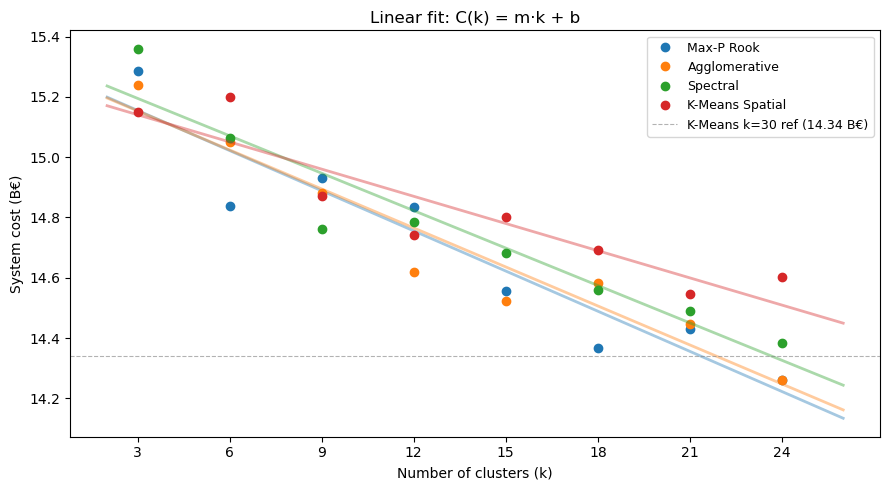

In [3]:
import os
import gc
import numpy as np
import calliope
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ── 1. Load all costs ───────────────────────────────────────────────────
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

records = []
for method in methods:
    for k in ks:
        path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue
        model = calliope.read_netcdf(path)
        records.append({'method': method, 'k': k, 'cost': float(model.results.cost.sum())})
        del model; gc.collect()

df = pd.DataFrame(records)

# k=30 reference
ref_path = f"{base_dir}/KMeans_Spatial/KMeans_Spatial_k30/weighted_percentile_timeseries/KMeans_Spatial_weighted_k30_bidirectional.nc"
ref_model = calliope.read_netcdf(ref_path)
ref_cost = float(ref_model.results.cost.sum())
del ref_model; gc.collect()

# ── 2. Linear fit: C(k) = m·k + b ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
k_smooth = np.linspace(2, 26, 200)

header = f"{'Method':<20} {'m (B€/k)':>10} {'b (B€)':>10} {'R²':>8} {'p(m)':>7} {'p(b)':>7}"
print(header)
print("-" * len(header))

for method in methods:
    sub = df[df['method'] == method].sort_values('k')
    k_data = sub['k'].values.astype(float)
    c_data = sub['cost'].values.astype(float)

    result = stats.linregress(k_data, c_data)
    m, b, r2 = result.slope, result.intercept, result.rvalue ** 2
    p_m, p_b = result.pvalue, result.intercept_stderr  # pvalue is for slope

    # p-value for intercept via t-test
    n_pts = len(k_data)
    t_b = b / result.intercept_stderr
    p_b = 2 * (1 - stats.t.cdf(abs(t_b), df=n_pts - 2))

    print(f"{method:<20} {m/1e6:>10.4f} {b/1e6:>10.2f} {r2:>8.4f} {result.pvalue:>7.4f} {p_b:>7.4f}")

    # Fitted line
    ax.plot(k_smooth, (m * k_smooth + b) / 1e6,
            color=colours[method], alpha=0.4, linewidth=2)

    # Data points
    ax.plot(k_data, c_data / 1e6, marker='o', linestyle='none',
            color=colours[method], label=labels[method], markersize=6)

ax.axhline(ref_cost / 1e6, color='grey', linestyle='--', linewidth=0.8, alpha=0.6,
           label=f'K-Means k=30 ref ({ref_cost/1e6:.2f} B€)')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('System cost (B€)')
ax.set_xticks(ks)
ax.legend(fontsize=9)
ax.set_title('Linear fit: C(k) = m·k + b')
plt.tight_layout()
plt.savefig('4YP_Figures/system_cost_linear_fit.png', dpi=150)
plt.show()

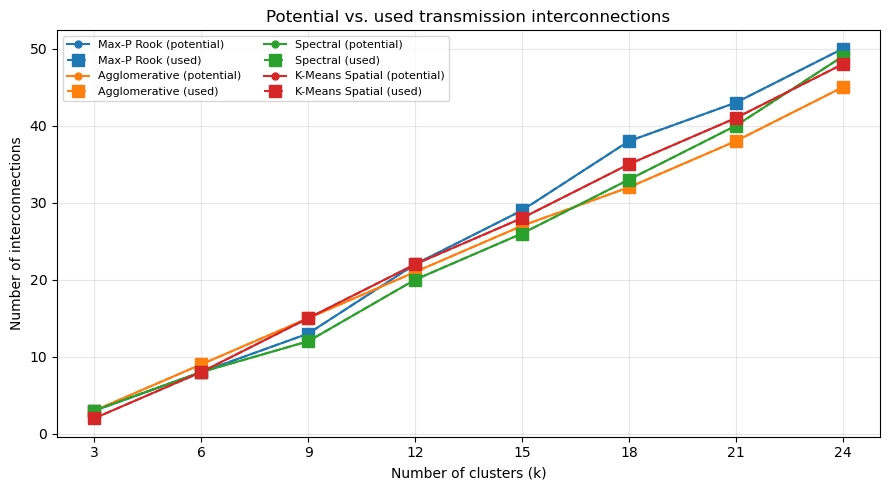

In [3]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24]
trans_techs = ['dc_transmission', 'hydrogen_pipeline', 'ammonia_pipeline']

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

fig, ax = plt.subplots(figsize=(9, 5))

for method in methods:
    potential, used, k_vals = [], [], []

    for k in ks:
        links_path = f"{base_dir}/{method}/{method}_k{k}/reduced_links.csv"
        nc_path    = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"

        if not os.path.exists(links_path) or not os.path.exists(nc_path):
            continue

        n_potential = len(pd.read_csv(links_path))

        # Use cost_investment > 0 to identify built links (avoids NaN issues with energy_cap)
        model = calliope.read_netcdf(nc_path)
        ci = model.results['cost_investment'].to_dataframe().reset_index()
        ci['tech']  = ci['loc_techs_investment_cost'].str.split('::').str[-1].str.split(':').str[0]
        ci['loc_a'] = ci['loc_techs_investment_cost'].str.split('::').str[0]
        ci['loc_b'] = ci['loc_techs_investment_cost'].str.split('::').str[-1].str.split(':').str[-1]
        ci_trans = ci[ci['tech'].isin(trans_techs)].copy()
        ci_trans['pair'] = ci_trans.apply(lambda r: tuple(sorted([r['loc_a'], r['loc_b']])), axis=1)
        n_used = ci_trans[ci_trans['cost_investment'] > 0]['pair'].nunique()

        del model; gc.collect()

        k_vals.append(k)
        potential.append(n_potential)
        used.append(n_used)

    ax.plot(k_vals, potential, marker='o', markersize=5,
            color=colours[method], linestyle='-',  label=f'{labels[method]} (potential)')
    ax.plot(k_vals, used,      marker='s', markersize=8,
            color=colours[method], linestyle='--', label=f'{labels[method]} (used)')

ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Number of interconnections')
ax.set_xticks(ks)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_title('Potential vs. used transmission interconnections')
plt.tight_layout()
plt.savefig('4YP_Figures/interconnections_potential_vs_used.png', dpi=150)
plt.show()

Method                 k   Potential   Used  Unused   % used
------------------------------------------------------------
MaxP_Rook              3           3      3       0   100.0%
MaxP_Rook              6           8      8       0   100.0%
MaxP_Rook              9          13     13       0   100.0%
MaxP_Rook             12          22     22       0   100.0%
MaxP_Rook             15          29     29       0   100.0%
MaxP_Rook             18          38     38       0   100.0%
MaxP_Rook             21          43     43       0   100.0%
MaxP_Rook             24          50     50       0   100.0%
Agglomerative          3           3      3       0   100.0%
Agglomerative          6           9      9       0   100.0%
Agglomerative          9          15     15       0   100.0%
Agglomerative         12          21     21       0   100.0%
Agglomerative         15          27     27       0   100.0%
Agglomerative         18          32     32       0   100.0%
Agglomerative         21

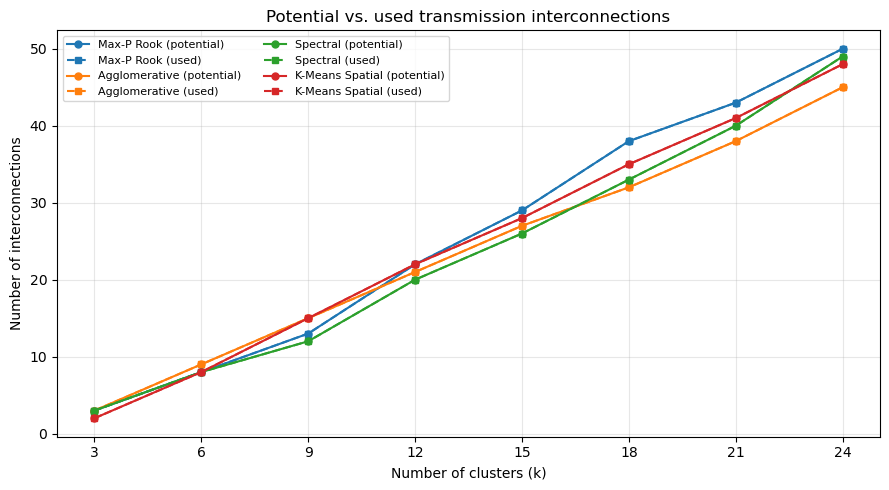

In [4]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24]
trans_techs = ['dc_transmission', 'hydrogen_pipeline', 'ammonia_pipeline']

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

print(f"{'Method':<20} {'k':>3}  {'Potential':>10} {'Used':>6} {'Unused':>7} {'% used':>8}")
print("-" * 60)

fig, ax = plt.subplots(figsize=(9, 5))

for method in methods:
    potential, used, k_vals = [], [], []

    for k in ks:
        links_path = f"{base_dir}/{method}/{method}_k{k}/reduced_links.csv"
        nc_path    = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"

        if not os.path.exists(links_path) or not os.path.exists(nc_path):
            continue

        n_potential = len(pd.read_csv(links_path))

        model = calliope.read_netcdf(nc_path)
        ci = model.results['cost_investment'].to_dataframe().reset_index()
        ci['tech']  = ci['loc_techs_investment_cost'].str.split('::').str[-1].str.split(':').str[0]
        ci['loc_a'] = ci['loc_techs_investment_cost'].str.split('::').str[0]
        ci['loc_b'] = ci['loc_techs_investment_cost'].str.split('::').str[-1].str.split(':').str[-1]
        ci_trans = ci[ci['tech'].isin(trans_techs)].copy()
        ci_trans['pair'] = ci_trans.apply(lambda r: tuple(sorted([r['loc_a'], r['loc_b']])), axis=1)

        built_pairs = ci_trans[ci_trans['cost_investment'] > 0]['pair'].unique()
        all_pairs   = ci_trans['pair'].unique()
        n_used      = len(built_pairs)
        n_all_pairs = len(all_pairs)

        # Print zero-investment links for inspection
        unbuilt = set(all_pairs) - set(built_pairs)
        print(f"{method:<20} {k:>3}  {n_potential:>10} {n_used:>6} {len(unbuilt):>7} {n_used/n_all_pairs*100:>7.1f}%")
        if unbuilt:
            print(f"   Unbuilt pairs: {list(unbuilt)[:3]}")  # show first 3

        del model; gc.collect()

        k_vals.append(k)
        potential.append(n_potential)
        used.append(n_used)

    ax.plot(k_vals, potential, marker='o', markersize=5,
            color=colours[method], linestyle='-',  label=f'{labels[method]} (potential)')
    ax.plot(k_vals, used,      marker='s', markersize=5,
            color=colours[method], linestyle='--', label=f'{labels[method]} (used)')

ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Number of interconnections')
ax.set_xticks(ks)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_title('Potential vs. used transmission interconnections')
plt.tight_layout()
plt.savefig('4YP_Figures/interconnections_potential_vs_used.png', dpi=150)
plt.show()

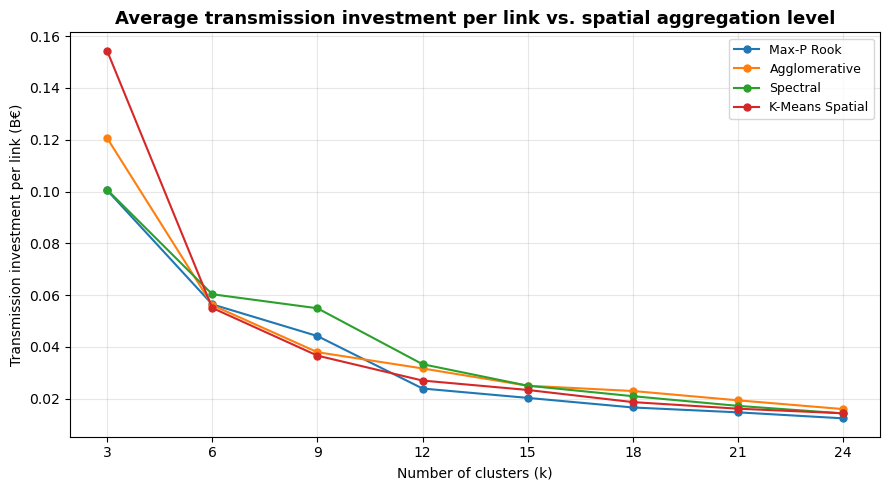

In [5]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24]
trans_techs = ['dc_transmission', 'hydrogen_pipeline', 'ammonia_pipeline']

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

fig, ax = plt.subplots(figsize=(9, 5))

for method in methods:
    records = []

    for k in ks:
        links_path = f"{base_dir}/{method}/{method}_k{k}/reduced_links.csv"
        nc_path    = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(links_path) or not os.path.exists(nc_path):
            continue

        n_links = len(pd.read_csv(links_path))

        model = calliope.read_netcdf(nc_path)
        ci = model.results['cost_investment'].to_dataframe().reset_index()
        ci['tech'] = ci['loc_techs_investment_cost'].str.split('::').str[-1].str.split(':').str[0]
        total_trans_invest = ci[ci['tech'].isin(trans_techs)]['cost_investment'].sum()
        del model; gc.collect()

        records.append({'k': k, 'per_link_B': (total_trans_invest / 1e6) / n_links if n_links > 0 else 0})

    df_m = pd.DataFrame(records).sort_values('k')
    ax.plot(df_m['k'], df_m['per_link_B'], marker='o', markersize=5,
            color=colours[method], label=labels[method])

ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Transmission investment per link (B€)')
ax.set_xticks(ks)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title('Average transmission investment per link vs. spatial aggregation level',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('4YP_Figures/transmission_per_link_vs_k.png', dpi=150)
plt.show()

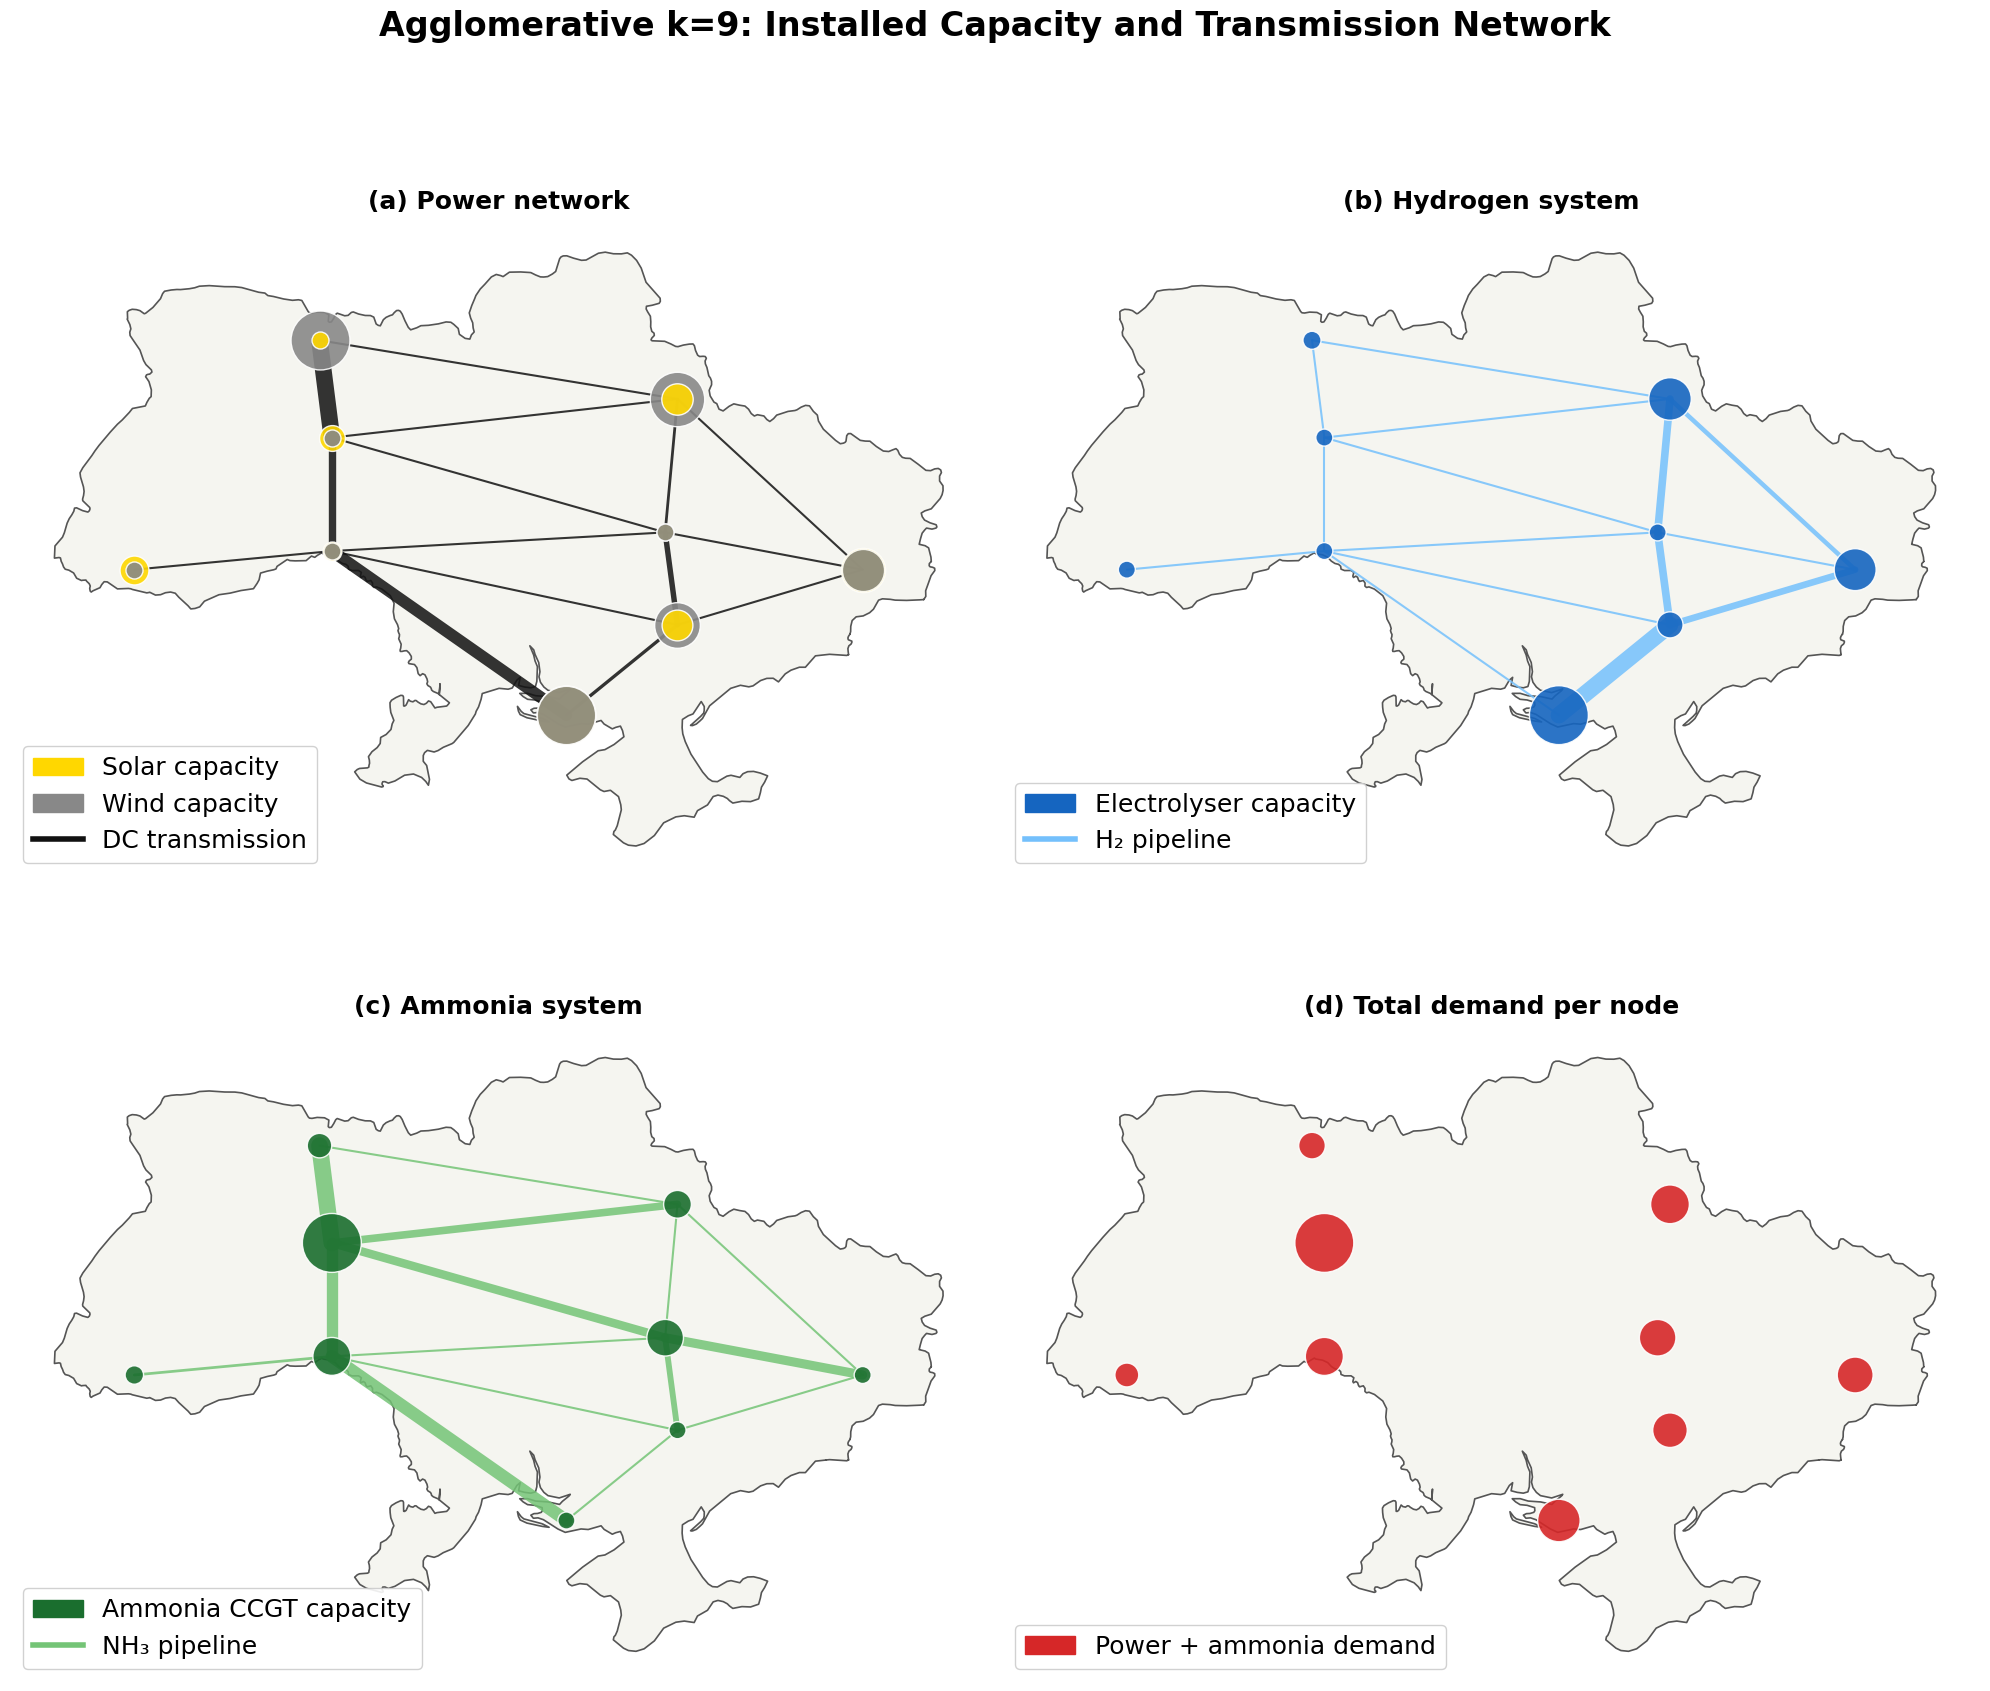

In [6]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import geopandas as gpd
from shapely.geometry import Point, LineString

# ── Config ────────────────────────────────────────────────────────────────
method = 'Agglomerative'
k = 9
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
cluster_dir = f'{base_dir}/{method}/{method}_k{k}'
nc_path = f'{cluster_dir}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc'

# ── Ukraine outline ───────────────────────────────────────────────────────
ukraine = gpd.read_file('data_prep/data/ukraine_merged_dissolved_noholes.geojson').to_crs('EPSG:3857')

# ── Helpers ───────────────────────────────────────────────────────────────
def make_region_name(lat, lon):
    return f"region_{lat}_{lon}".replace('.', '_')

def parse_loc_tech(s):
    parts = s.split('::')
    loc_from = parts[0]
    tech_part = parts[1]
    if ':' in tech_part:
        idx = tech_part.index(':')
        return pd.Series([loc_from, tech_part[:idx], tech_part[idx+1:]])
    return pd.Series([loc_from, tech_part, None])

# ── Node metadata ─────────────────────────────────────────────────────────
meta = pd.read_csv(f'{cluster_dir}/cluster_metadata.csv')
meta['region_name'] = meta.apply(lambda r: make_region_name(r['lat'], r['lon']), axis=1)
node_coords = dict(zip(meta['region_name'], zip(meta['lon'], meta['lat'])))

# ── Load .nc results ──────────────────────────────────────────────────────
model = calliope.read_netcdf(nc_path)
ec = model.results.energy_cap.to_dataframe().reset_index()
ec.columns = ['loc_techs', 'energy_cap']
ec = ec[ec['energy_cap'].notna() & (ec['energy_cap'] > 0)].copy()
ec[['loc_from', 'tech', 'loc_to']] = ec['loc_techs'].apply(parse_loc_tech)

ec_point = ec[ec['loc_to'].isna()].copy()
ec_trans  = ec[ec['loc_to'].notna()].copy()
ec_trans['pair'] = ec_trans.apply(lambda r: tuple(sorted([r['loc_from'], r['loc_to']])), axis=1)
ec_trans = ec_trans.drop_duplicates(subset=['pair', 'tech'])

# ── Demand ────────────────────────────────────────────────────────────────
demand_df = pd.read_csv(f'{cluster_dir}/cluster_demand_profiles.csv', index_col=0)
avg_power = demand_df.abs().mean()
meta['power_demand'] = meta['cluster_id'].apply(lambda cid: avg_power.get(f'cluster_{int(cid)}', 0))
meta['total_demand'] = meta['power_demand'] + meta['ammonia_demand_MWh_hourly']

for tech in ['solar_single_axis', 'onshore_wind', 'electrolyser', 'ammonia_ccgt']:
    sub = ec_point[ec_point['tech'] == tech].set_index('loc_from')['energy_cap']
    meta[tech] = meta['region_name'].map(sub).fillna(0)

del model; gc.collect()

# ── GeoDataFrame ──────────────────────────────────────────────────────────
node_gdf = gpd.GeoDataFrame(
    meta.copy(),
    geometry=[Point(r['lon'], r['lat']) for _, r in meta.iterrows()],
    crs='EPSG:4326'
).to_crs('EPSG:3857')

def make_link_gdf(tech_name):
    rows = []
    for _, row in ec_trans[ec_trans['tech'] == tech_name].iterrows():
        a, b = row['loc_from'], row['loc_to']
        if a in node_coords and b in node_coords:
            lon_a, lat_a = node_coords[a]
            lon_b, lat_b = node_coords[b]
            rows.append({'geometry': LineString([Point(lon_a, lat_a), Point(lon_b, lat_b)]),
                         'energy_cap': row['energy_cap']})
    return gpd.GeoDataFrame(rows, crs='EPSG:4326').to_crs('EPSG:3857') if rows else None

dc_links  = make_link_gdf('dc_transmission')
h2_links  = make_link_gdf('hydrogen_pipeline')
nh3_links = make_link_gdf('ammonia_pipeline')

# ── Plot helpers ──────────────────────────────────────────────────────────
def plot_ukraine(ax):
    ukraine.plot(ax=ax, facecolor='#f5f5f0', edgecolor='#555555', linewidth=1.2, zorder=0)

def plot_links(ax, link_gdf, color, min_lw=1.5, max_lw=12):
    if link_gdf is None or len(link_gdf) == 0:
        return
    max_cap = link_gdf['energy_cap'].max()
    for _, row in link_gdf.iterrows():
        lw = max(row['energy_cap'] / max_cap * max_lw, min_lw)
        xs, ys = row.geometry.xy
        ax.plot(xs, ys, color=color, linewidth=lw, alpha=0.85,
                solid_capstyle='round', zorder=2)

def scale_sizes(series, min_s=150, max_s=1800):
    s = series.copy()
    if s.max() == 0:
        return s * 0
    return (s / s.max()) * (max_s - min_s) + min_s

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(20, 18))

# ── Panel (a): Power network — solar (yellow) + wind (grey) + DC lines (black) ──
ax = axes[0, 0]
plot_ukraine(ax)
plot_links(ax, dc_links, color='#111111')

# Plot larger capacity behind smaller: compare solar vs wind per node and draw larger first
solar_sizes = scale_sizes(node_gdf['solar_single_axis'])
wind_sizes  = scale_sizes(node_gdf['onshore_wind'])

for idx, row in node_gdf.iterrows():
    ss = solar_sizes[idx]
    ws = wind_sizes[idx]
    # Draw larger behind smaller
    if ss >= ws:
        ax.scatter(row.geometry.x, row.geometry.y, s=ss, c='#FFD700',
                   alpha=0.9, zorder=3, edgecolors='white', linewidths=1.0)
        ax.scatter(row.geometry.x, row.geometry.y, s=ws, c='#888888',
                   alpha=0.9, zorder=4, edgecolors='white', linewidths=1.0)
    else:
        ax.scatter(row.geometry.x, row.geometry.y, s=ws, c='#888888',
                   alpha=0.9, zorder=3, edgecolors='white', linewidths=1.0)
        ax.scatter(row.geometry.x, row.geometry.y, s=ss, c='#FFD700',
                   alpha=0.9, zorder=4, edgecolors='white', linewidths=1.0)

ax.set_axis_off()
ax.set_title('(a) Power network', fontsize=18, fontweight='bold', pad=10)
ax.legend(handles=[
    mpatches.Patch(color='#FFD700', label='Solar capacity'),
    mpatches.Patch(color='#888888', label='Wind capacity'),
    mlines.Line2D([], [], color='#111111', linewidth=4, label='DC transmission'),
], fontsize=18, loc='lower left', framealpha=0.9)

# ── Panel (b): Hydrogen — dark blue nodes + light blue lines ──────────────
ax = axes[0, 1]
plot_ukraine(ax)
plot_links(ax, h2_links, color='#74c0fc')
h2_sizes = scale_sizes(node_gdf['electrolyser'])
ax.scatter(node_gdf.geometry.x, node_gdf.geometry.y, s=h2_sizes,
           c='#1565C0', alpha=0.9, zorder=3, edgecolors='white', linewidths=1.0)
ax.set_axis_off()
ax.set_title('(b) Hydrogen system', fontsize=18, fontweight='bold', pad=10)
ax.legend(handles=[
    mpatches.Patch(color='#1565C0', label='Electrolyser capacity'),
    mlines.Line2D([], [], color='#74c0fc', linewidth=4, label='H₂ pipeline'),
], fontsize=18, loc='lower left', framealpha=0.9)

# ── Panel (c): Ammonia — dark green nodes + light green lines ────────────
ax = axes[1, 0]
plot_ukraine(ax)
plot_links(ax, nh3_links, color='#74c476')
nh3_sizes = scale_sizes(node_gdf['ammonia_ccgt'])
ax.scatter(node_gdf.geometry.x, node_gdf.geometry.y, s=nh3_sizes,
           c='#1a6e2e', alpha=0.9, zorder=3, edgecolors='white', linewidths=1.0)
ax.set_axis_off()
ax.set_title('(c) Ammonia system', fontsize=18, fontweight='bold', pad=10)
ax.legend(handles=[
    mpatches.Patch(color='#1a6e2e', label='Ammonia CCGT capacity'),
    mlines.Line2D([], [], color='#74c476', linewidth=4, label='NH₃ pipeline'),
], fontsize=18, loc='lower left', framealpha=0.9)

# ── Panel (d): Total demand — red nodes ──────────────────────────────────
ax = axes[1, 1]
plot_ukraine(ax)
dem_sizes = scale_sizes(node_gdf['total_demand'])
ax.scatter(node_gdf.geometry.x, node_gdf.geometry.y, s=dem_sizes,
           c='#d62728', alpha=0.9, zorder=3, edgecolors='white', linewidths=1.0)
ax.set_axis_off()
ax.set_title('(d) Total demand per node', fontsize=18, fontweight='bold', pad=10)
ax.legend(handles=[
    mpatches.Patch(color='#d62728', label='Power + ammonia demand'),
], fontsize=18, loc='lower left', framealpha=0.9)

fig.suptitle(f'Agglomerative k={k}: Installed Capacity and Transmission Network',
             fontsize=24, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('4YP_Figures/agglomerative_k9_capacity_network.png', dpi=200, bbox_inches='tight')
plt.show()

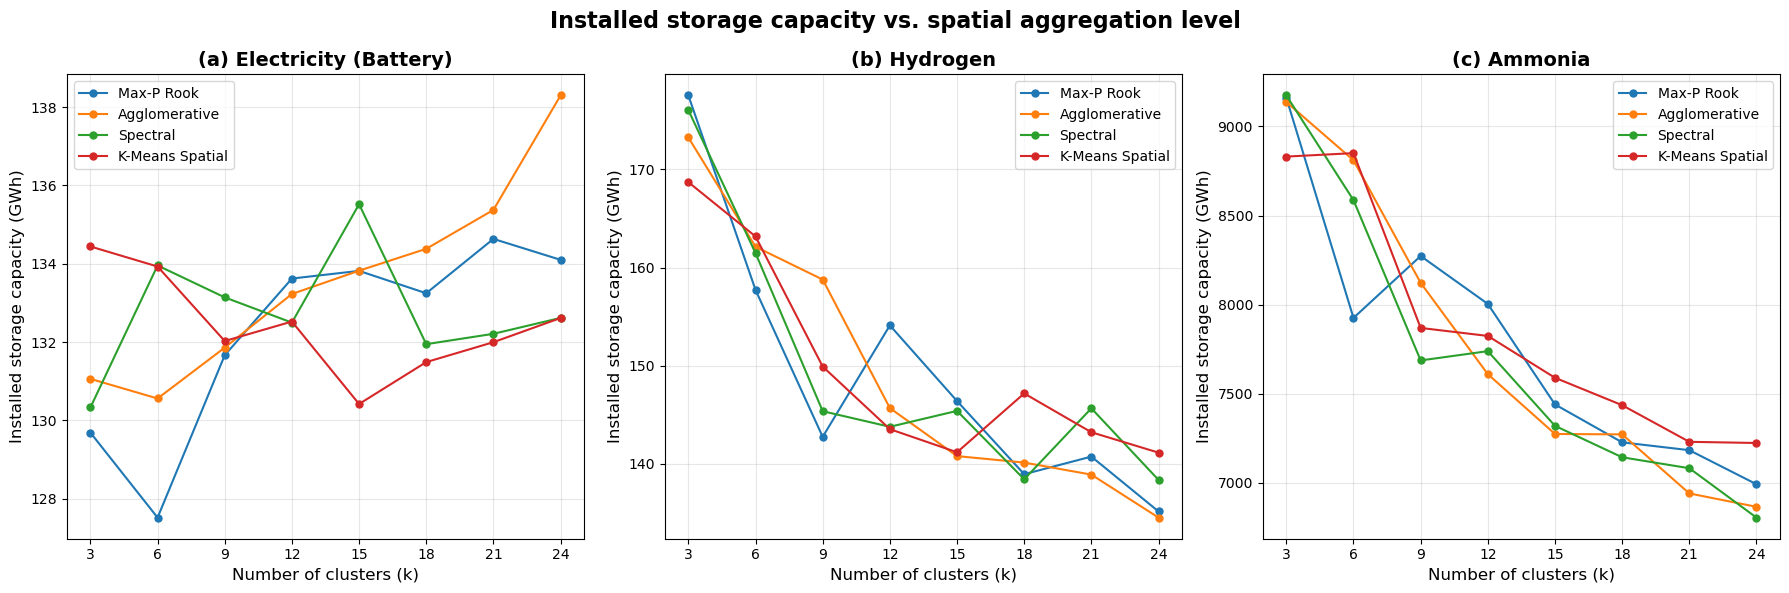

In [1]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

# Storage tech groupings
storage_groups = {
    'Electricity (Battery)': ['battery'],
    'Hydrogen':              ['compressed_hydrogen_storage', 'cavern_hydrogen_storage'],
    'Ammonia':               ['ammonia_storage'],
}

# ── Load storage capacities ───────────────────────────────────────────────
all_records = {m: [] for m in methods}

for method in methods:
    for k in ks:
        nc_path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(nc_path):
            continue

        model = calliope.read_netcdf(nc_path)
        sc = model.results.storage_cap.to_dataframe().reset_index()
        sc.columns = ['loc_techs', 'storage_cap']
        sc['tech'] = sc['loc_techs'].str.split('::').str[-1]
        sc = sc[sc['storage_cap'].notna()]
        tech_totals = sc.groupby('tech')['storage_cap'].sum()

        row = {'k': k}
        for group, techs in storage_groups.items():
            row[group] = sum(tech_totals.get(t, 0) for t in techs) / 1e3  # MWh → GWh

        all_records[method].append(row)
        del model; gc.collect()

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

panel_labels = ['(a)', '(b)', '(c)']

for idx, (group, techs) in enumerate(storage_groups.items()):
    ax = axes[idx]
    for method in methods:
        if not all_records[method]:
            continue
        df_m = pd.DataFrame(all_records[method]).sort_values('k')
        ax.plot(df_m['k'], df_m[group], marker='o', markersize=5,
                color=colours[method], label=labels[method])

    ax.set_title(f'{panel_labels[idx]} {group}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of clusters (k)', fontsize=12)
    ax.set_ylabel('Installed storage capacity (GWh)', fontsize=12)
    ax.set_xticks(ks)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

fig.suptitle('Installed storage capacity vs. spatial aggregation level',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('4YP_Figures/storage_capacity_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

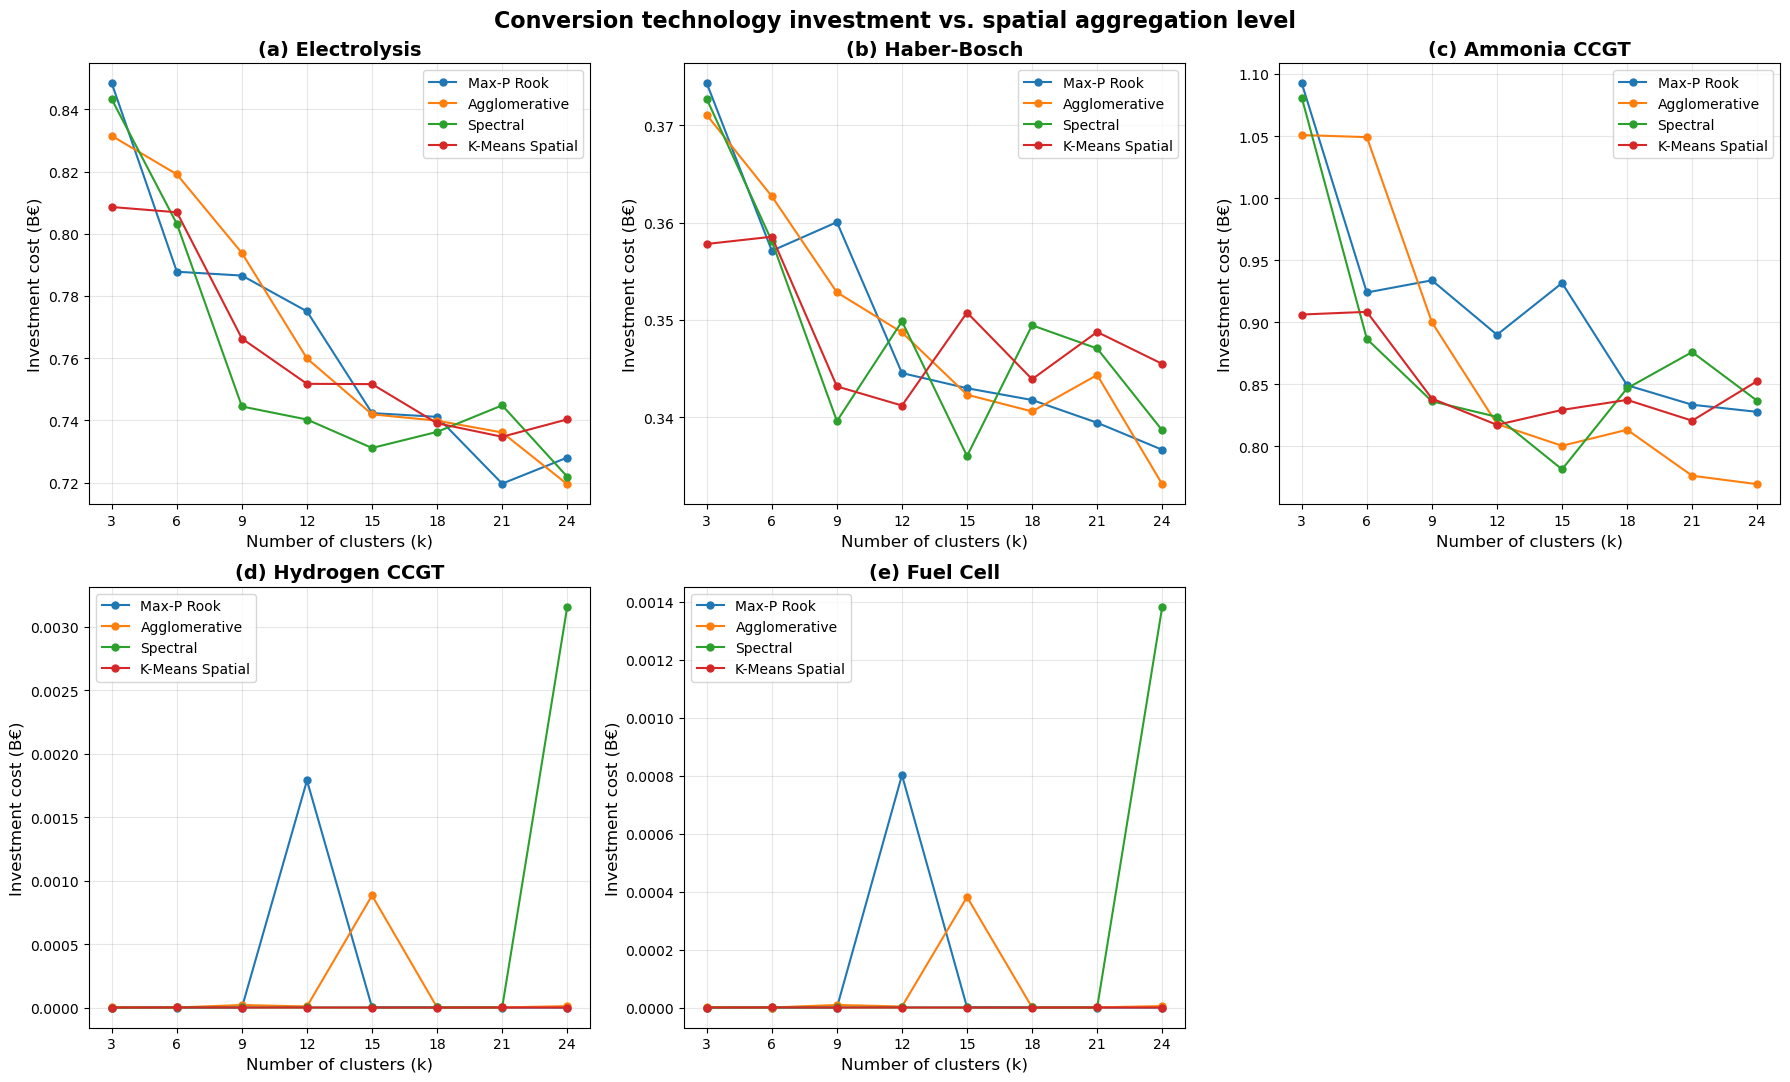

In [2]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

conversion_techs = {
    '(a) Electrolysis':    'electrolyser',
    '(b) Haber-Bosch':     'haber_and_air_separation',
    '(c) Ammonia CCGT':    'ammonia_ccgt',
    '(d) Hydrogen CCGT':   'hydrogen_ccgt',
    '(e) Fuel Cell':       'fuel_cell',
}

# ── Load investment costs ─────────────────────────────────────────────────
all_records = {m: [] for m in methods}

for method in methods:
    for k in ks:
        nc_path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(nc_path):
            continue

        model = calliope.read_netcdf(nc_path)
        ci = model.results['cost_investment'].to_dataframe().reset_index()
        ci['tech'] = ci['loc_techs_investment_cost'].str.split('::').str[-1].str.split(':').str[0]
        ci = ci[ci['cost_investment'].notna()]
        tech_totals = ci.groupby('tech')['cost_investment'].sum()

        row = {'k': k}
        for title, tech in conversion_techs.items():
            row[title] = tech_totals.get(tech, 0) / 1e6  # k€ → B€

        all_records[method].append(row)
        del model; gc.collect()

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharey=False)
axes_flat = axes.flatten()

for idx, title in enumerate(conversion_techs):
    ax = axes_flat[idx]
    for method in methods:
        if not all_records[method]:
            continue
        df_m = pd.DataFrame(all_records[method]).sort_values('k')
        ax.plot(df_m['k'], df_m[title], marker='o', markersize=5,
                color=colours[method], label=labels[method])

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of clusters (k)', fontsize=12)
    ax.set_ylabel('Investment cost (B€)', fontsize=12)
    ax.set_xticks(ks)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

# Hide unused 6th panel
axes_flat[-1].set_visible(False)

fig.suptitle('Conversion technology investment vs. spatial aggregation level',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('4YP_Figures/conversion_investment_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

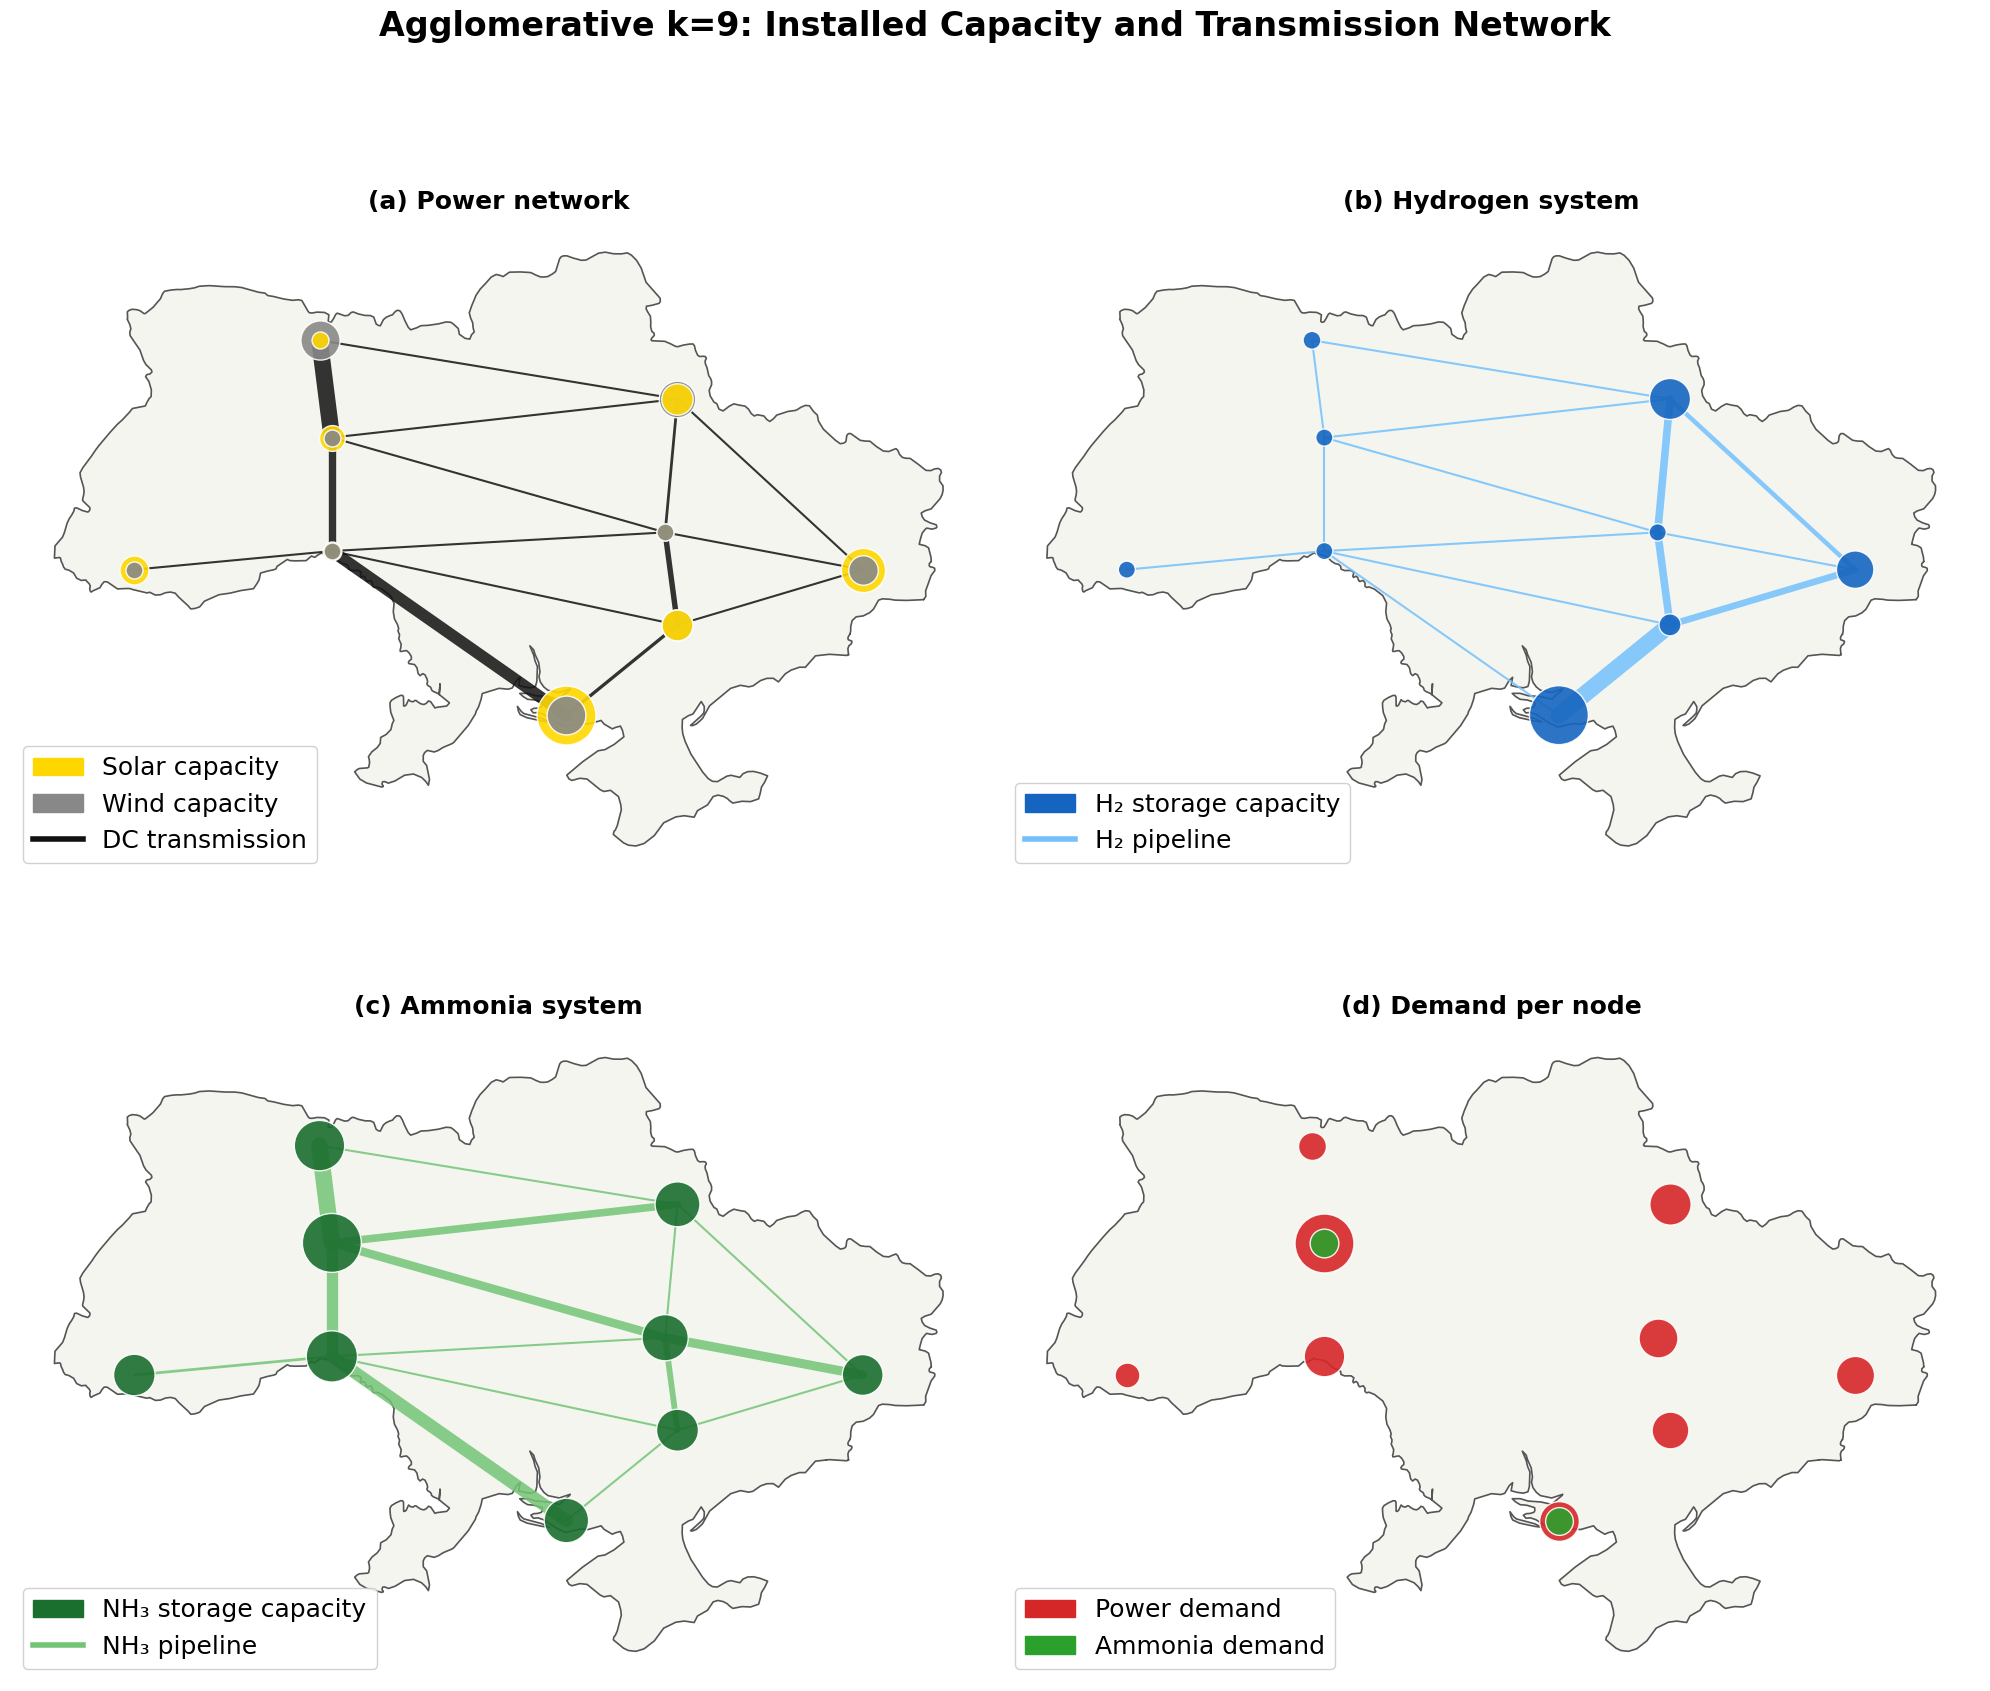

In [8]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import geopandas as gpd
from shapely.geometry import Point, LineString

# ── Config ────────────────────────────────────────────────────────────────
method = 'Agglomerative'
k = 9
base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
cluster_dir = f'{base_dir}/{method}/{method}_k{k}'
nc_path = f'{cluster_dir}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc'

# ── Ukraine outline ───────────────────────────────────────────────────────
ukraine = gpd.read_file('data_prep/data/ukraine_merged_dissolved_noholes.geojson').to_crs('EPSG:3857')

# ── Helpers ───────────────────────────────────────────────────────────────
def make_region_name(lat, lon):
    return f"region_{lat}_{lon}".replace('.', '_')

def parse_loc_tech(s):
    parts = s.split('::')
    loc_from = parts[0]
    tech_part = parts[1]
    if ':' in tech_part:
        idx = tech_part.index(':')
        return pd.Series([loc_from, tech_part[:idx], tech_part[idx+1:]])
    return pd.Series([loc_from, tech_part, None])

MIN_S, MAX_S = 150, 1800

def scale_to_common(series, common_max):
    """Scale series using a shared maximum so relative sizes are meaningful."""
    if common_max == 0:
        return series * 0
    return (series / common_max) * (MAX_S - MIN_S) + MIN_S

# ── Node metadata ─────────────────────────────────────────────────────────
meta = pd.read_csv(f'{cluster_dir}/cluster_metadata.csv')
meta['region_name'] = meta.apply(lambda r: make_region_name(r['lat'], r['lon']), axis=1)
node_coords = dict(zip(meta['region_name'], zip(meta['lon'], meta['lat'])))

# ── Load .nc results ──────────────────────────────────────────────────────
model = calliope.read_netcdf(nc_path)

# energy_cap
ec = model.results.energy_cap.to_dataframe().reset_index()
ec.columns = ['loc_techs', 'energy_cap']
ec = ec[ec['energy_cap'].notna() & (ec['energy_cap'] > 0)].copy()
ec[['loc_from', 'tech', 'loc_to']] = ec['loc_techs'].apply(parse_loc_tech)
ec_point = ec[ec['loc_to'].isna()].copy()
ec_trans  = ec[ec['loc_to'].notna()].copy()
ec_trans['pair'] = ec_trans.apply(lambda r: tuple(sorted([r['loc_from'], r['loc_to']])), axis=1)
ec_trans = ec_trans.drop_duplicates(subset=['pair', 'tech'])

# storage_cap
sc = model.results.storage_cap.to_dataframe().reset_index()
sc.columns = ['loc_techs', 'storage_cap']
sc['tech']     = sc['loc_techs'].str.split('::').str[-1]
sc['loc_from'] = sc['loc_techs'].str.split('::').str[0]
sc = sc[sc['storage_cap'].notna() & (sc['storage_cap'] > 0)]

# ── Demand ────────────────────────────────────────────────────────────────
demand_df = pd.read_csv(f'{cluster_dir}/cluster_demand_profiles.csv', index_col=0)
avg_power = demand_df.abs().mean()
meta['power_demand'] = meta['cluster_id'].apply(lambda cid: avg_power.get(f'cluster_{int(cid)}', 0))

# ── Point capacities from energy_cap ─────────────────────────────────────
for tech in ['solar_single_axis', 'onshore_wind']:
    sub = ec_point[ec_point['tech'] == tech].set_index('loc_from')['energy_cap']
    meta[tech] = meta['region_name'].map(sub).fillna(0)

# Storage per node
for col, techs in [('h2_storage',  ['compressed_hydrogen_storage', 'cavern_hydrogen_storage']),
                   ('nh3_storage', ['ammonia_storage'])]:
    sub = sc[sc['tech'].isin(techs)].groupby('loc_from')['storage_cap'].sum()
    meta[col] = meta['region_name'].map(sub).fillna(0)

del model; gc.collect()

# ── GeoDataFrame ──────────────────────────────────────────────────────────
node_gdf = gpd.GeoDataFrame(
    meta.copy(),
    geometry=[Point(r['lon'], r['lat']) for _, r in meta.iterrows()],
    crs='EPSG:4326'
).to_crs('EPSG:3857')

def make_link_gdf(tech_name):
    rows = []
    for _, row in ec_trans[ec_trans['tech'] == tech_name].iterrows():
        a, b = row['loc_from'], row['loc_to']
        if a in node_coords and b in node_coords:
            lon_a, lat_a = node_coords[a]
            lon_b, lat_b = node_coords[b]
            rows.append({'geometry': LineString([Point(lon_a, lat_a), Point(lon_b, lat_b)]),
                         'energy_cap': row['energy_cap']})
    return gpd.GeoDataFrame(rows, crs='EPSG:4326').to_crs('EPSG:3857') if rows else None

dc_links  = make_link_gdf('dc_transmission')
h2_links  = make_link_gdf('hydrogen_pipeline')
nh3_links = make_link_gdf('ammonia_pipeline')

# ── Plot helpers ──────────────────────────────────────────────────────────
def plot_ukraine(ax):
    ukraine.plot(ax=ax, facecolor='#f5f5f0', edgecolor='#555555', linewidth=1.2, zorder=0)

def plot_links(ax, link_gdf, color, min_lw=1.5, max_lw=12):
    if link_gdf is None or len(link_gdf) == 0:
        return
    max_cap = link_gdf['energy_cap'].max()
    for _, row in link_gdf.iterrows():
        lw = max(row['energy_cap'] / max_cap * max_lw, min_lw)
        xs, ys = row.geometry.xy
        ax.plot(xs, ys, color=color, linewidth=lw, alpha=0.85,
                solid_capstyle='round', zorder=2)

def plot_dual_nodes(ax, gdf, col_back, color_back, col_front, color_front,
                    common_max, mask_front=None):
    """
    Plot two markers per node scaled to a common max.
    Larger always drawn first (zorder 3), smaller on top (zorder 4).
    mask_front: boolean Series — if False, skip drawing the front marker.
    """
    sizes_back  = scale_to_common(gdf[col_back],  common_max)
    sizes_front = scale_to_common(gdf[col_front], common_max)

    for idx, row in gdf.iterrows():
        sb = sizes_back[idx]
        sf = sizes_front[idx]
        show_front = (mask_front is None or mask_front[idx])

        # Always draw back layer
        ax.scatter(row.geometry.x, row.geometry.y, s=sb, c=color_back,
                   alpha=0.9, zorder=3, edgecolors='white', linewidths=1.0)
        # Only draw front layer if non-zero and permitted
        if show_front and sf > 0:
            ax.scatter(row.geometry.x, row.geometry.y, s=sf, c=color_front,
                       alpha=0.9, zorder=4, edgecolors='white', linewidths=1.0)

# ── Figure ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(20, 18))

# ── Panel (a): Power network — solar + wind scaled to common max ──────────
ax = axes[0, 0]
plot_ukraine(ax)
plot_links(ax, dc_links, color='#111111')

gen_max = max(node_gdf['solar_single_axis'].max(), node_gdf['onshore_wind'].max())
# Draw larger behind, smaller in front per node
solar_s = scale_to_common(node_gdf['solar_single_axis'], gen_max)
wind_s  = scale_to_common(node_gdf['onshore_wind'],      gen_max)
for idx, row in node_gdf.iterrows():
    ss, ws = solar_s[idx], wind_s[idx]
    if ss >= ws:
        ax.scatter(row.geometry.x, row.geometry.y, s=ss, c='#FFD700',
                   alpha=0.9, zorder=3, edgecolors='white', linewidths=1.0)
        ax.scatter(row.geometry.x, row.geometry.y, s=ws, c='#888888',
                   alpha=0.9, zorder=4, edgecolors='white', linewidths=1.0)
    else:
        ax.scatter(row.geometry.x, row.geometry.y, s=ws, c='#888888',
                   alpha=0.9, zorder=3, edgecolors='white', linewidths=1.0)
        ax.scatter(row.geometry.x, row.geometry.y, s=ss, c='#FFD700',
                   alpha=0.9, zorder=4, edgecolors='white', linewidths=1.0)

ax.set_axis_off()
ax.set_title('(a) Power network', fontsize=18, fontweight='bold', pad=10)
ax.legend(handles=[
    mpatches.Patch(color='#FFD700', label='Solar capacity'),
    mpatches.Patch(color='#888888', label='Wind capacity'),
    mlines.Line2D([], [], color='#111111', linewidth=4, label='DC transmission'),
], fontsize=18, loc='lower left', framealpha=0.9)

# ── Panel (b): Hydrogen — storage capacity ────────────────────────────────
ax = axes[0, 1]
plot_ukraine(ax)
plot_links(ax, h2_links, color='#74c0fc')
h2_sizes = scale_to_common(node_gdf['h2_storage'], node_gdf['h2_storage'].max())
ax.scatter(node_gdf.geometry.x, node_gdf.geometry.y, s=h2_sizes,
           c='#1565C0', alpha=0.9, zorder=3, edgecolors='white', linewidths=1.0)
ax.set_axis_off()
ax.set_title('(b) Hydrogen system', fontsize=18, fontweight='bold', pad=10)
ax.legend(handles=[
    mpatches.Patch(color='#1565C0', label='H₂ storage capacity'),
    mlines.Line2D([], [], color='#74c0fc', linewidth=4, label='H₂ pipeline'),
], fontsize=18, loc='lower left', framealpha=0.9)

# ── Panel (c): Ammonia — storage capacity ────────────────────────────────
ax = axes[1, 0]
plot_ukraine(ax)
plot_links(ax, nh3_links, color='#74c476')
nh3_sizes = scale_to_common(node_gdf['nh3_storage'], node_gdf['nh3_storage'].max())
ax.scatter(node_gdf.geometry.x, node_gdf.geometry.y, s=nh3_sizes,
           c='#1a6e2e', alpha=0.9, zorder=3, edgecolors='white', linewidths=1.0)
ax.set_axis_off()
ax.set_title('(c) Ammonia system', fontsize=18, fontweight='bold', pad=10)
ax.legend(handles=[
    mpatches.Patch(color='#1a6e2e', label='NH₃ storage capacity'),
    mlines.Line2D([], [], color='#74c476', linewidth=4, label='NH₃ pipeline'),
], fontsize=18, loc='lower left', framealpha=0.9)

# ── Panel (d): Power (red) + Ammonia demand (green) ──────────────────────
ax = axes[1, 1]
plot_ukraine(ax)

dem_max = max(node_gdf['power_demand'].max(), node_gdf['ammonia_demand_MWh_hourly'].max())
nh3_mask = node_gdf['ammonia_demand_MWh_hourly'] > 0

# Power always drawn on top; ammonia behind where present
nh3_dem_s = scale_to_common(node_gdf['ammonia_demand_MWh_hourly'], dem_max)
power_s   = scale_to_common(node_gdf['power_demand'],              dem_max)

for idx, row in node_gdf.iterrows():
    ps = power_s[idx]
    ns = nh3_dem_s[idx] if nh3_mask[idx] else 0
    ax.scatter(row.geometry.x, row.geometry.y, s=ps, c='#d62728',
               alpha=0.9, zorder=3, edgecolors='white', linewidths=1.0)
    if ns > 0:
        ax.scatter(row.geometry.x, row.geometry.y, s=ns, c='#2ca02c',
                   alpha=0.9, zorder=4, edgecolors='white', linewidths=1.0)

ax.set_axis_off()
ax.set_title('(d) Demand per node', fontsize=18, fontweight='bold', pad=10)
ax.legend(handles=[
    mpatches.Patch(color='#d62728', label='Power demand'),
    mpatches.Patch(color='#2ca02c', label='Ammonia demand'),
], fontsize=18, loc='lower left', framealpha=0.9)

fig.suptitle(f'Agglomerative k={k}: Installed Capacity and Transmission Network',
             fontsize=24, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('4YP_Figures/agglomerative_k9_capacity_network.png', dpi=200, bbox_inches='tight')
plt.show()

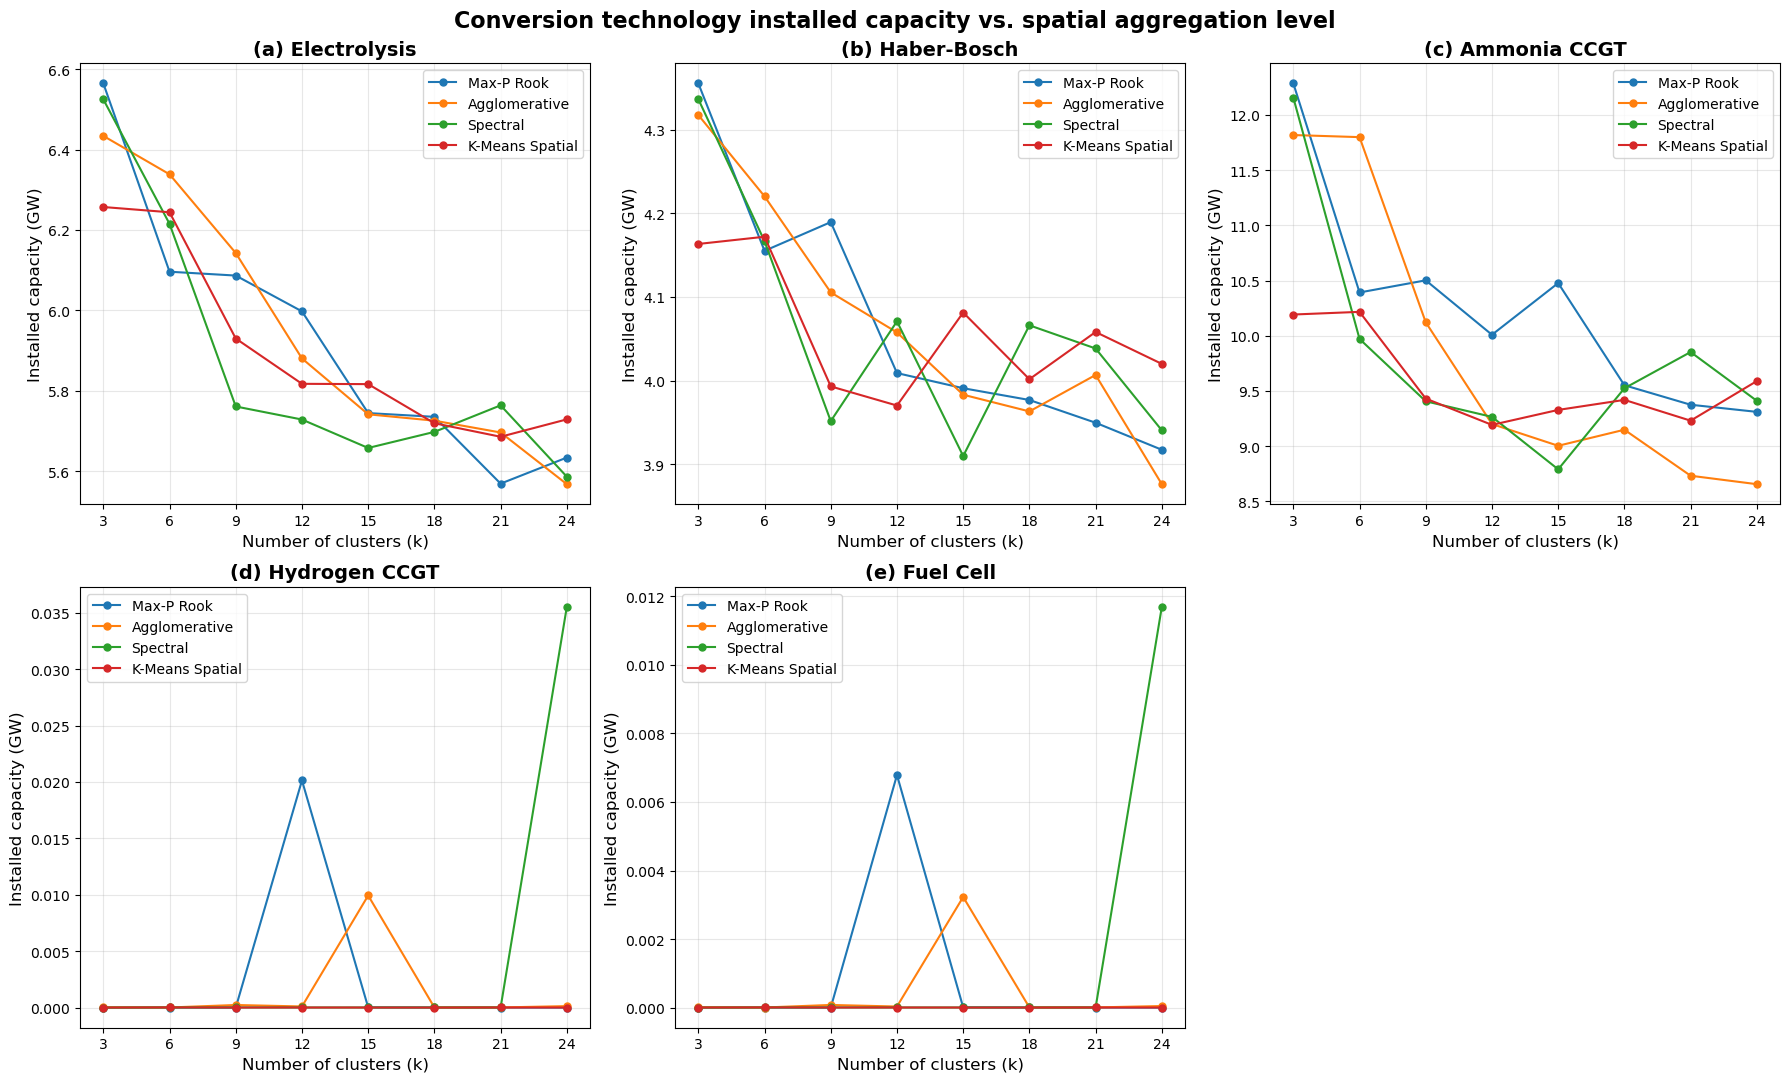

In [3]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

conversion_techs = {
    '(a) Electrolysis':  'electrolyser',
    '(b) Haber-Bosch':   'haber_and_air_separation',
    '(c) Ammonia CCGT':  'ammonia_ccgt',
    '(d) Hydrogen CCGT': 'hydrogen_ccgt',
    '(e) Fuel Cell':     'fuel_cell',
}

# ── Load installed capacities ─────────────────────────────────────────────
all_records = {m: [] for m in methods}

for method in methods:
    for k in ks:
        nc_path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(nc_path):
            continue

        model = calliope.read_netcdf(nc_path)
        ec = model.results.energy_cap.to_dataframe().reset_index()
        ec.columns = ['loc_techs', 'energy_cap']
        ec['tech'] = ec['loc_techs'].str.split('::').str[-1].str.split(':').str[0]
        ec = ec[ec['energy_cap'].notna()]
        tech_totals = ec.groupby('tech')['energy_cap'].sum()

        row = {'k': k}
        for title, tech in conversion_techs.items():
            row[title] = tech_totals.get(tech, 0) / 1e3  # MW → GW

        all_records[method].append(row)
        del model; gc.collect()

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharey=False)
axes_flat = axes.flatten()

for idx, title in enumerate(conversion_techs):
    ax = axes_flat[idx]
    for method in methods:
        if not all_records[method]:
            continue
        df_m = pd.DataFrame(all_records[method]).sort_values('k')
        ax.plot(df_m['k'], df_m[title], marker='o', markersize=5,
                color=colours[method], label=labels[method])

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of clusters (k)', fontsize=12)
    ax.set_ylabel('Installed capacity (GW)', fontsize=12)
    ax.set_xticks(ks)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

axes_flat[-1].set_visible(False)

fig.suptitle('Conversion technology installed capacity vs. spatial aggregation level',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('4YP_Figures/conversion_capacity_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

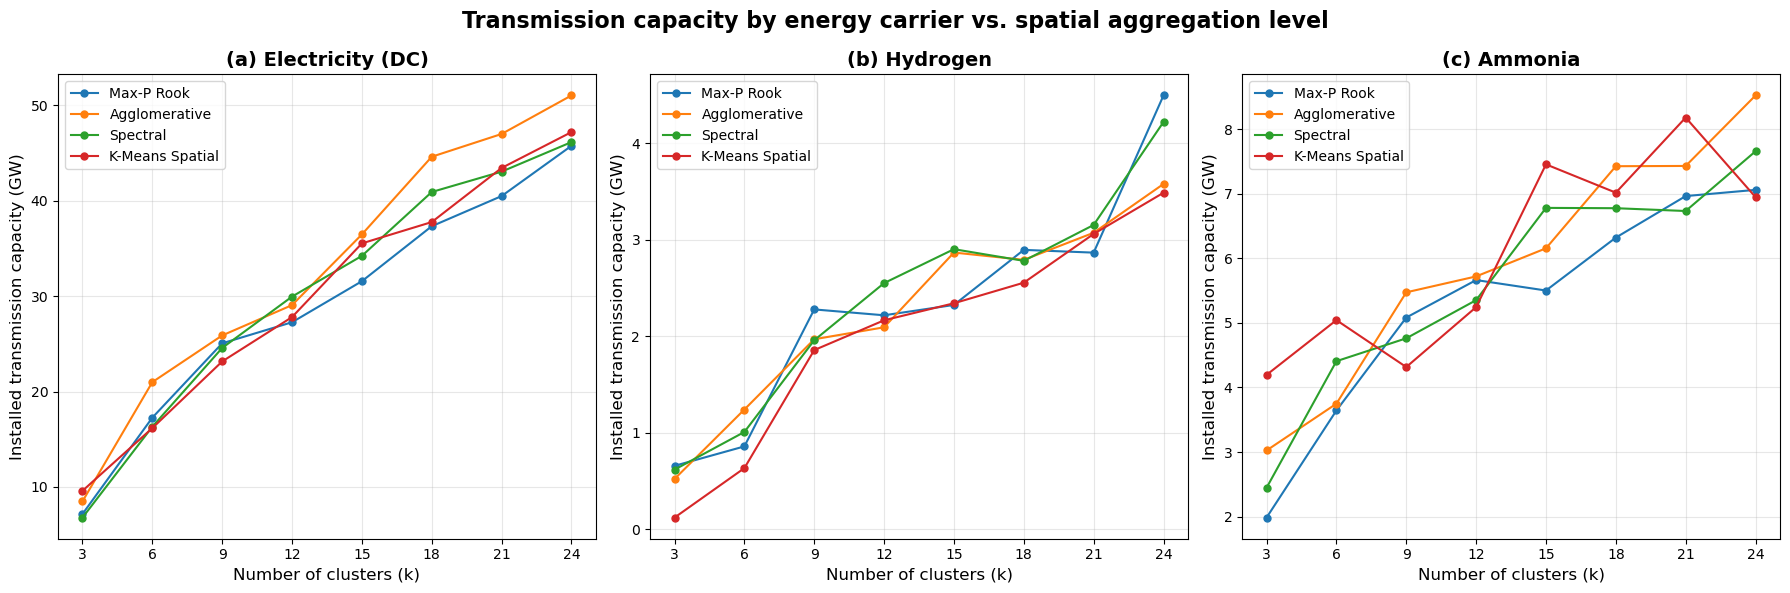

In [2]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

transmission_techs = {
    '(a) Electricity (DC)': 'dc_transmission',
    '(b) Hydrogen':         'hydrogen_pipeline',
    '(c) Ammonia':          'ammonia_pipeline',
}

# ── Load transmission capacities ──────────────────────────────────────────
all_records = {m: [] for m in methods}

for method in methods:
    for k in ks:
        nc_path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(nc_path):
            continue

        model = calliope.read_netcdf(nc_path)
        ec = model.results.energy_cap.to_dataframe().reset_index()
        ec.columns = ['loc_techs', 'energy_cap']
        # Transmission techs have the form "loc_a::tech:loc_b" — filter by tech name
        ec['tech'] = ec['loc_techs'].str.split('::').str[-1].str.split(':').str[0]
        ec = ec[ec['energy_cap'].notna()]
        # Each link appears twice (both directions) — deduplicate by taking half the sum
        tech_totals = ec.groupby('tech')['energy_cap'].sum() / 2

        row = {'k': k}
        for title, tech in transmission_techs.items():
            row[title] = tech_totals.get(tech, 0) / 1e3  # MW → GW

        all_records[method].append(row)
        del model; gc.collect()

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for idx, title in enumerate(transmission_techs):
    ax = axes[idx]
    for method in methods:
        if not all_records[method]:
            continue
        df_m = pd.DataFrame(all_records[method]).sort_values('k')
        ax.plot(df_m['k'], df_m[title], marker='o', markersize=5,
                color=colours[method], label=labels[method])

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of clusters (k)', fontsize=12)
    ax.set_ylabel('Installed transmission capacity (GW)', fontsize=12)
    ax.set_xticks(ks)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

fig.suptitle('Transmission capacity by energy carrier vs. spatial aggregation level',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('4YP_Figures/transmission_capacity_by_carrier_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

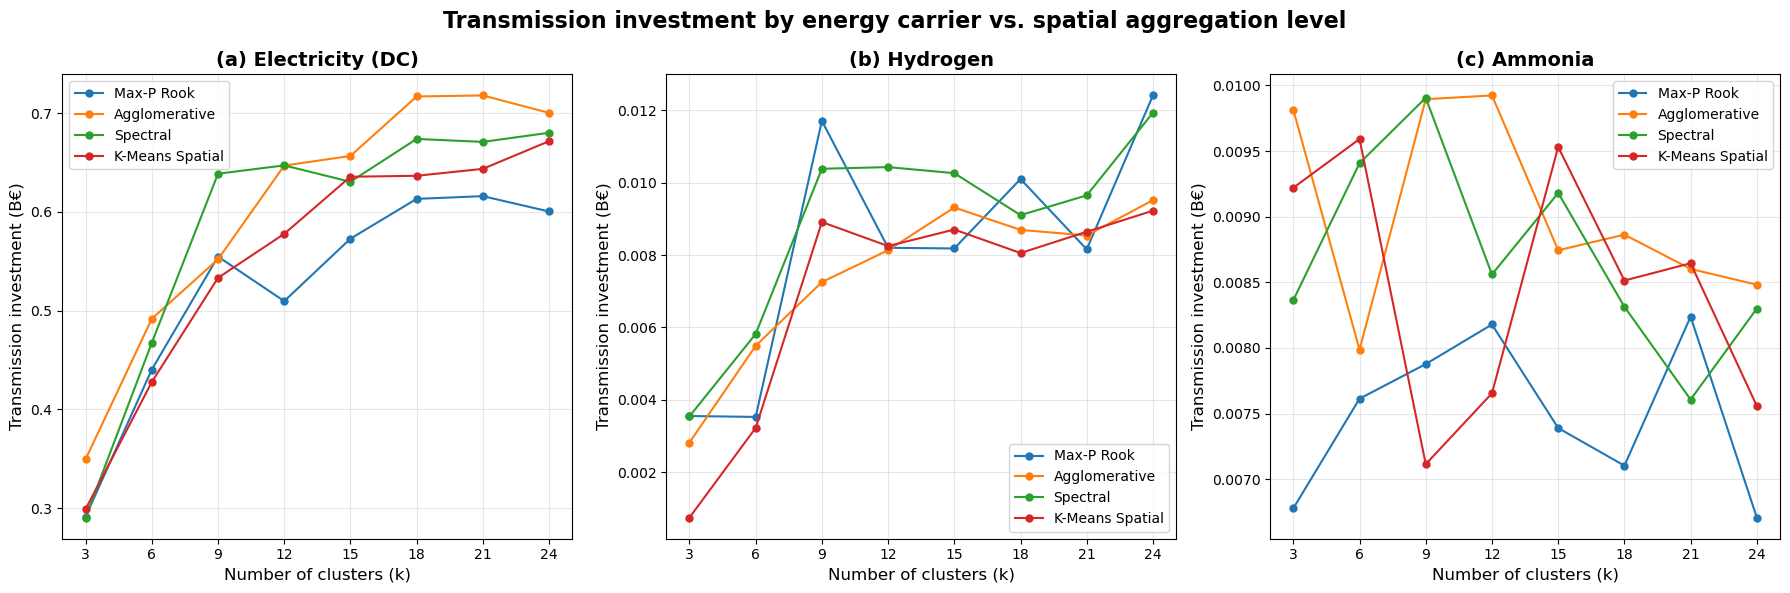

In [4]:
import os
import gc
import calliope
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = 'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional'
methods = ['MaxP_Rook', 'Agglomerative', 'Spectral', 'KMeans_Spatial']
ks = [3, 6, 9, 12, 15, 18, 21, 24]

colours = {'MaxP_Rook': '#1f77b4', 'Agglomerative': '#ff7f0e', 'Spectral': '#2ca02c', 'KMeans_Spatial': '#d62728'}
labels  = {'MaxP_Rook': 'Max-P Rook', 'Agglomerative': 'Agglomerative', 'Spectral': 'Spectral', 'KMeans_Spatial': 'K-Means Spatial'}

transmission_techs = {
    '(a) Electricity (DC)': 'dc_transmission',
    '(b) Hydrogen':         'hydrogen_pipeline',
    '(c) Ammonia':          'ammonia_pipeline',
}

# ── Load transmission investment ──────────────────────────────────────────
all_records = {m: [] for m in methods}

for method in methods:
    for k in ks:
        nc_path = f"{base_dir}/{method}/{method}_k{k}/weighted_percentile_timeseries/{method}_weighted_k{k}_bidirectional.nc"
        if not os.path.exists(nc_path):
            continue

        model = calliope.read_netcdf(nc_path)
        ci = model.results['cost_investment'].to_dataframe().reset_index()
        ci['tech'] = ci['loc_techs_investment_cost'].str.split('::').str[-1].str.split(':').str[0]
        ci = ci[ci['cost_investment'].notna()]
        tech_totals = ci.groupby('tech')['cost_investment'].sum()

        row = {'k': k}
        for title, tech in transmission_techs.items():
            row[title] = tech_totals.get(tech, 0) / 1e6  # k€ → B€

        all_records[method].append(row)
        del model; gc.collect()

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for idx, title in enumerate(transmission_techs):
    ax = axes[idx]
    for method in methods:
        if not all_records[method]:
            continue
        df_m = pd.DataFrame(all_records[method]).sort_values('k')
        ax.plot(df_m['k'], df_m[title], marker='o', markersize=5,
                color=colours[method], label=labels[method])

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of clusters (k)', fontsize=12)
    ax.set_ylabel('Transmission investment (B€)', fontsize=12)
    ax.set_xticks(ks)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

fig.suptitle('Transmission investment by energy carrier vs. spatial aggregation level',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('4YP_Figures/transmission_investment_by_carrier_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

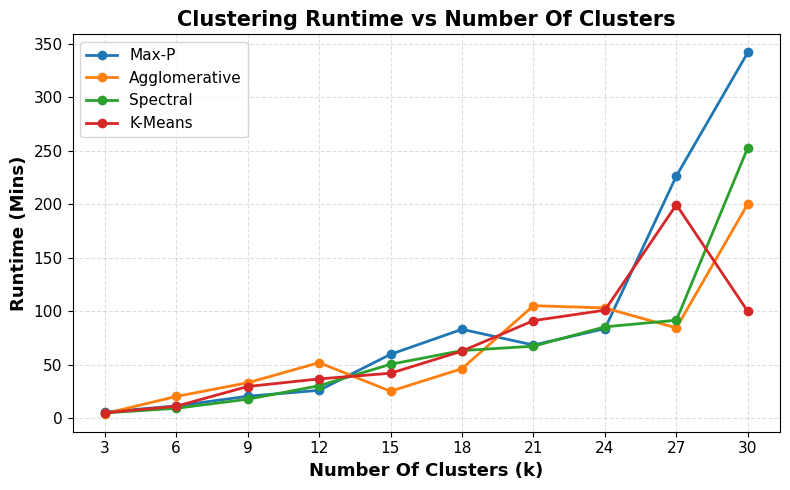

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

runtime = pd.read_csv(
    'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/cluster_runtime.csv',
    index_col=0
)
runtime.columns = runtime.columns.astype(int)

# Match project colour convention
colours = {
    'MaxP_Rook':           '#1f77b4',
    'Agglomerative':  '#ff7f0e',
    'Spectral':       '#2ca02c',
    'Kmeans_Spatial':         '#d62728'
}
labels = {
    'MaxP_Rook':          'Max-P',
    'Agglomerative': 'Agglomerative',
    'Spectral':      'Spectral',
    'Kmeans_Spatial':        'K-Means'
}

fig, ax = plt.subplots(figsize=(8, 5))

for method, row in runtime.iterrows():
    ax.plot(row.index, row.values, marker='o', linewidth=2, markersize=6,
            color=colours[method], label=labels[method])

ax.set_xlabel('Number Of Clusters (k)', fontsize=13, fontweight='bold')
ax.set_ylabel('Runtime (Mins)', fontsize=13, fontweight='bold')
ax.set_title('Clustering Runtime vs Number Of Clusters', fontsize=15, fontweight='bold')
ax.set_xticks(runtime.columns)
ax.tick_params(axis='both', which='major', labelsize=11)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('4YP_Figures/clustering_runtime_vs_k.png', dpi=200, bbox_inches='tight')
plt.show()

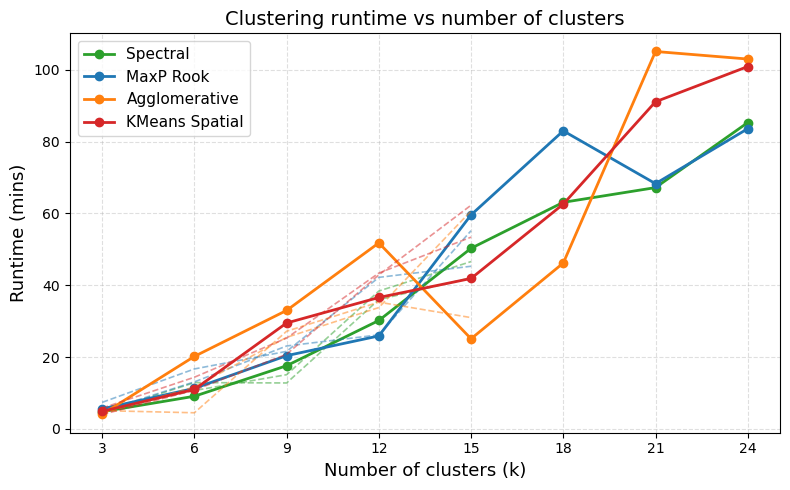

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

runtime = pd.read_csv(
    'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/cluster_runtime.csv',
    index_col=0
)
runtime.columns = runtime.columns.astype(int)

sens = pd.read_csv(
    'data_prep/Clustering_Output/KNN_Graph_output/nodal_ammonia_bidirectional/cluster_sensitivity_runtime.csv',
    index_col=0
)
sens.columns = sens.columns.astype(int)

colours = {
    'Spectral':       '#2ca02c',
    'MaxP_Rook':      '#1f77b4',
    'Agglomerative':  '#ff7f0e',
    'Kmeans_Spatial': '#d62728',
}
labels = {
    'Spectral':       'Spectral',
    'MaxP_Rook':      'MaxP Rook',
    'Agglomerative':  'Agglomerative',
    'Kmeans_Spatial': 'KMeans Spatial',
}
sens_prefix = {
    'Spectral':       'Spectral',
    'MaxP_Rook':      'MaxP',
    'Agglomerative':  'Agglomerative',
    'Kmeans_Spatial': 'Kmeans',
}

fig, ax = plt.subplots(figsize=(8, 5))

for method in ['Spectral', 'MaxP_Rook', 'Agglomerative', 'Kmeans_Spatial']:
    colour = colours[method]
    prefix = sens_prefix[method]

    # 10th and 90th percentile as dashed lines
    low  = sens.loc[f'{prefix}_10th']
    high = sens.loc[f'{prefix}_90th']
    ax.plot(low.index,  low.values,  linestyle='--', linewidth=1.2, color=colour, alpha=0.5)
    ax.plot(high.index, high.values, linestyle='--', linewidth=1.2, color=colour, alpha=0.5)

    # Main runtime line
    row = runtime.loc[method]
    ax.plot(row.index, row.values, marker='o', linewidth=2, markersize=6,
            color=colour, label=labels[method])

ax.set_xlabel('Number of clusters (k)', fontsize=13)
ax.set_ylabel('Runtime (mins)', fontsize=13)
ax.set_title('Clustering runtime vs number of clusters', fontsize=14)
ax.set_xticks(runtime.columns)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()